Saving gusa.edf to gusa.edf


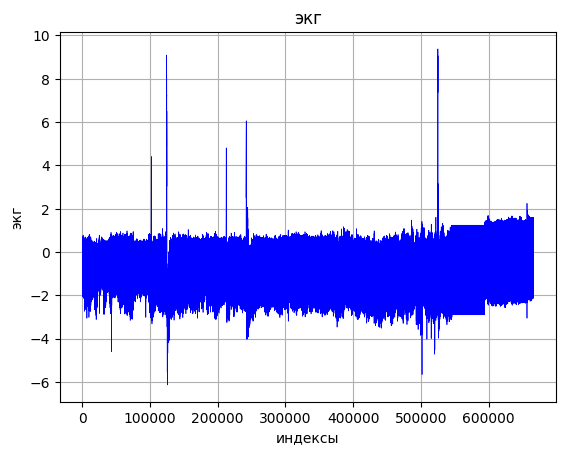

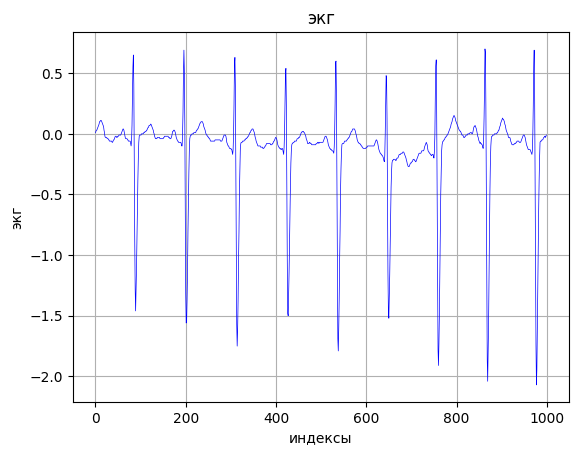

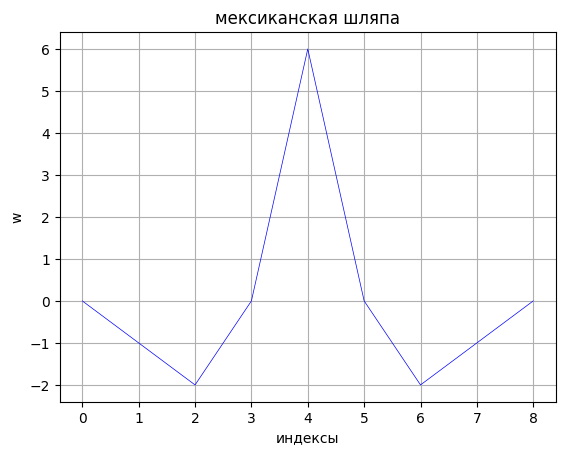

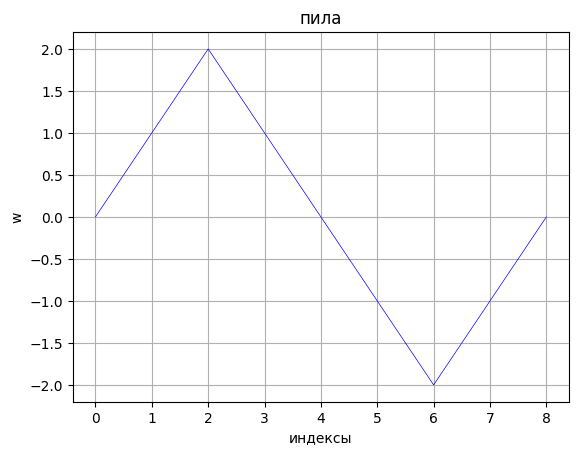

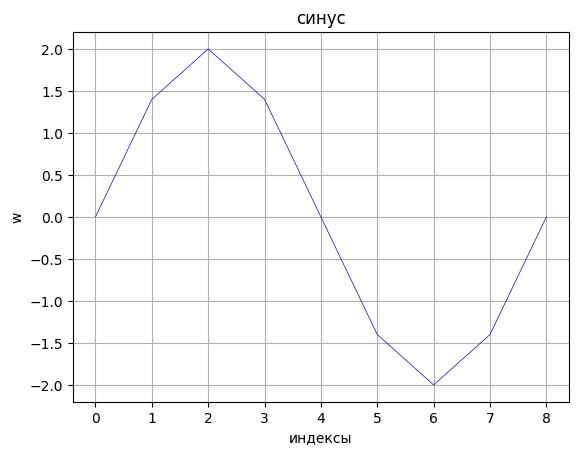

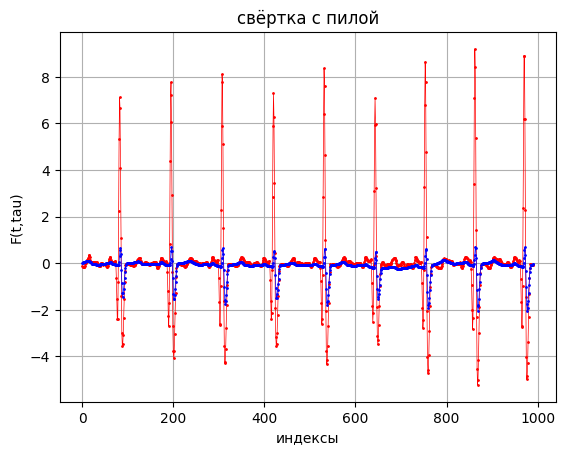

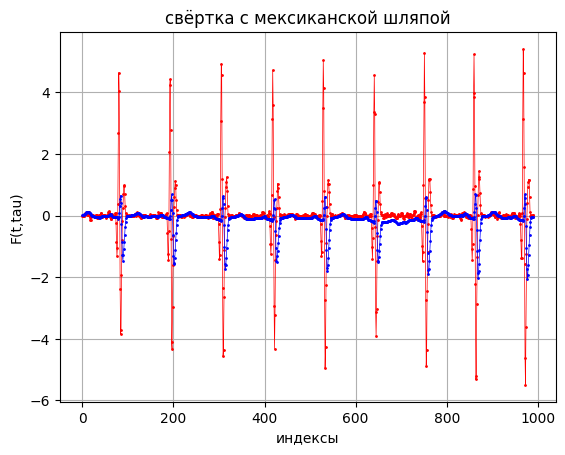

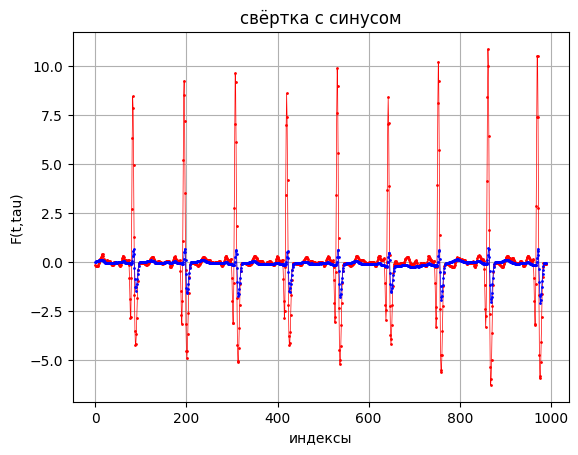

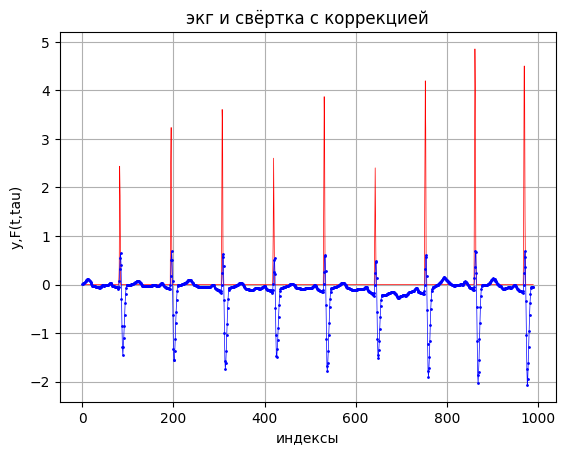

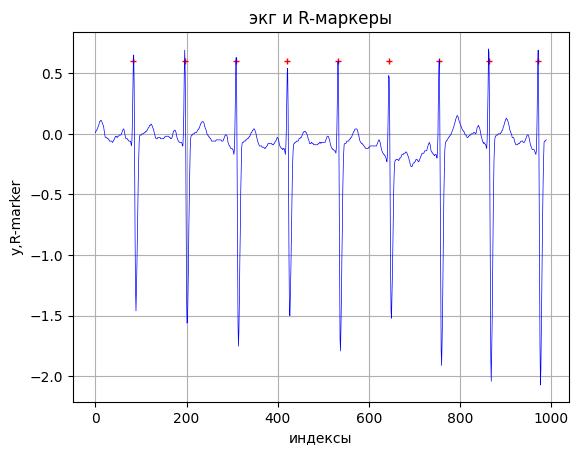

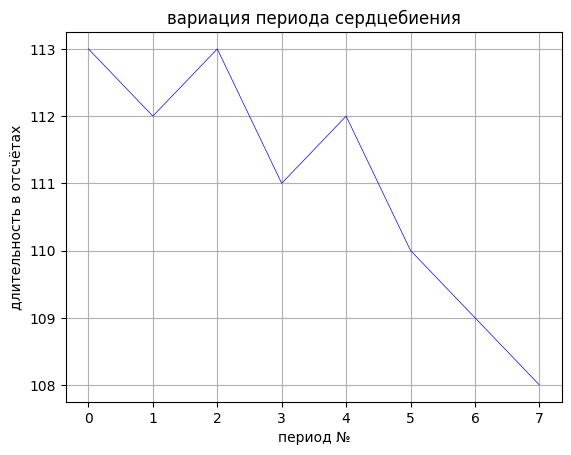

In [ ]:
#скрипт идентификации R зубцов, чтение файлов встроенное
#с вводом интервалов индексов вручную

#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
from google.colab import files # For file uploads
import matplotlib.pyplot as plt
from math import pi as pi
import math

#root = Tk()
#диалог открытия файла
#fid = filedialog.askopenfilename()

# To fix the Tkinter error in Colab, provide the file path directly.
# Replace '/path/to/your/file' with the actual path to your file after uploading.
#диалог открытия файла
uploaded = files.upload()

# Assuming only one file is uploaded, get the filename
fid = list(uploaded.keys())[0]

with open(fid,'rb') as f:
    #HEADER
    vers = float(f.read(8))#номер версии файла
    patientID = f.read(80).decode('utf-8')#ID пациента
    patientID = patientID.strip()#обрезание пробелов в начале и конце
    recordID = f.read(80).decode('utf-8')#ID записи
    recordID = recordID.strip()#обрезание пробелов в начале и конце
    startdate = f.read(8).decode('utf-8')#дата начала записи (dd.mm.yy)
    startdate = startdate.strip()#обрезание пробелов в начале и конце
    starttime = f.read(8).decode('utf-8')#время начала записи (hh.mm.ss)
    starttime = starttime.strip()#обрезание пробелов в начале и конце
    numBytes = int(f.read(8))#число байт
    reserved = f.read(44).decode('utf-8')#зарезервировано
    reserved = reserved.strip()#обрезание пробелов в начале и конце
    numRec = int(f.read(8))#число записей
    duration = float(f.read(8))#длительность записи
    ns = int(f.read(4))#число сигналов
    #создаётся пустой список меток
    label = []
    for ii in range(ns):#чтение меток = ответвлений
        label.append(f.read(16).decode('utf-8'))#добавление в список
        label[ii] = label[ii].strip()#обрезание пробелов в начале и конце
    #создаётся пустой список преобразователей? что это?
    transducer = []
    for ii in range(ns):#чтение преобразователей
        transducer.append(f.read(80).decode('utf-8'))#добавление в список
    #единицы измерения (мВ, мкВ, любые другие)
    units = []
    for ii in range(ns):#чтение
        units.append(f.read(8).decode('utf-8'))#добавление в список
        units[ii] = units[ii].strip()#обрезание пробелов в начале и конце
    #минимальное значение
    physicalMin = []
    for ii in range(ns):#чтение
        physicalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение
    physicalMax = []
    for ii in range(ns):#чтение
        physicalMax.append(float(f.read(8)))#добавление в список
    #минимальное значение в дискретах
    digitalMin = []
    for ii in range(ns):#чтение
        digitalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение в дискретах
    digitalMax = []
    for ii in range(ns):#чтение
        digitalMax.append(float(f.read(8)))#добавление в список
    #префильтр
    prefilter = []
    for ii in range(ns):#чтение
        prefilter.append(f.read(80).decode('utf-8'))#добавление в список
        prefilter[ii] = prefilter[ii].strip()#обрезание пробелов в начале и конце
    #отсчёты
    samples = []
    for ii in range(ns):#чтение
        samples.append(int(f.read(8)))#добавление в список
    #резервы сигналов
    reserv_ns = []
    for ii in range(ns):#чтение
        reserv_ns.append(f.read(32).decode('utf-8'))#добавление в список
        reserv_ns[ii] = reserv_ns[ii].strip()#обрезание пробелов в начале и конце
    #вычисление масштабного множителя для перевода дискрет в mV
    scalefac = []
    for ii in range(ns):
        sc_tmp = (physicalMax[ii] - physicalMin[ii])/(digitalMax[ii] - digitalMin[ii])
        scalefac.append(sc_tmp)
    #постоянная составляющая - корректор нуля
    dc = []
    for ii in range(ns):
        dc_tmp = physicalMax[ii] - scalefac[ii]*digitalMax[ii]
        dc.append(dc_tmp)
    #чтение данных:одно значение "целое со знаком" записано в 2 байта в порядке little
    #это когда последний байт знаковый. Соответственно этому задаются параметры метода
    #int.from_bytes - чтение 2 байт, byteorder='little',signed=True
    #ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ
    data_s = []
    for ii in range (samples[0]):
        data_tmp =  int.from_bytes(f.read(2),byteorder='little',signed=True)
        data_s.append(data_tmp*scalefac[0]+dc[0])
#ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ

#задание диапазона индексов  для всей записи
xt = samples[0];
#построение обзорного графика
x=[]
for ii in range (xt):
    x.append(ii)

#построение графика 1-го сигнала
plt.plot(x, data_s,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#список диапазона индексов
#range_ind=[0,0]
#
# Removed Tkinter dialogs for index input
# root = Tk()
# root.withdraw()
# showinfo(title='цикл ввода диапазона индексов',
#          message='ввод [нач.,кон.], выхода из цикла [0,0]')

#цикл ввода индексов
# while True:
#     root = Tk()
#     root.withdraw()
#     tmp_beg = int(simpledialog.askstring(title='',
#                                   prompt='начальный индекс'))
#     root = Tk()
#     root.withdraw()
#     tmp_end = int(simpledialog.askstring(title='',
#                                   prompt='конечный индекс'))

#     if tmp_beg >= tmp_end:
#          break
#     range_beg = tmp_beg
#     range_end = tmp_end

# To fix the Tkinter error in Colab, provide the range directly.
# Replace the values with your desired range.
range_beg = 0
range_end = 1000 # Example range

#построение обзорного графика
x=[]
for ii in range (range_beg,range_end):
    x.append(ii)

#построение обзорного графика сигнала
plt.plot(x, data_s[range_beg:range_end],'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#часть 2 - выделение QRS комплексов
#вейвлет
wav1=(0,-1,-2,0,6,0,-2,-1,0)#шляпа
wav2=(0,1,2,1,0,-1,-2,-1,0)#пила
wav3=(0,1.4,2,1.4,0,-1.4,-2,-1.4,0)#синус

x_wav=[]
for ii in range (9):
    x_wav.append(ii)

#применённые вейвлеты
plt.plot(x_wav, wav1,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('мексиканская шляпа') #Название
plt.grid(True)
plt.show()

plt.plot(x_wav, wav2,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('пила') #Название
plt.grid(True)
plt.show()

plt.plot(x_wav, wav3,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('синус') #Название
plt.grid(True)
plt.show()

#генерация свёртки и построение графиков
#пила
xs=[]
for ii in range (range_beg,range_end-len(wav2)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav2)):
    integr=0
    for ii in range (len(wav2)):#размер wav2
        integr=integr+data_s[kk+ii]*wav2[ii]
    ws.append(integr)

#построение вейвлет-образа с пилой
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav2)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с пилой') #Название
plt.grid(True)
plt.show()

#шляпа
xs=[]
for ii in range (range_beg,range_end-len(wav1)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav1)):
    integr=0
    for ii in range (len(wav3)):#размер wav1
        integr=integr+data_s[kk+ii]*wav1[ii]
    ws.append(integr)

#построение вейвлет-образа с шляпой
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav1)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с мексиканской шляпой') #Название
plt.grid(True)
plt.show()

#синус
xs=[]
for ii in range (range_beg,range_end-len(wav3)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav3)):
    integr=0
    for ii in range (len(wav3)):#размер wav3
        integr=integr+data_s[kk+ii]*wav3[ii]
    ws.append(integr)

#построение вейвлет-образа
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav3)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с синусом') #Название
plt.grid(True)
plt.show()


#коррекция вейвлет-образа - обнуление всего что меньше порога
porog = 6
for ii in range (len(ws)):
    if ws[ii]-porog < 0 : ws[ii]=0
    else : ws[ii]=ws[ii]-porog

#графики свёртки и исходного сигнала
plt.plot(xs, ws,'r-',xs,data_s[range_beg:range_end-len(wav3)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y,F(t,tau)') #Подпись для оси y
plt.title('экг и свёртка с коррекцией') #Название
plt.grid(True)
plt.show()

#вычисление индексов R зубцов в отдельный список
indR=[]
yR=[]
kk=0 #счётчик indR
ii=1 #счётчик ws
tmp_max=0
flag=False

while ii <= len(ws)-1:
    if ws[ii]>tmp_max:#путь к максимуму
        tmp_max=ws[ii]
        flag=True
    else:#здесь начало падения, фиксация R
        if flag:
            indR.append(range_beg+ii) #коррекция вершины
            yR.append(0.6)#ординаты отображаемых точек R
            tmp_max=ws[ii]
            flag=False
            kk=kk+1
        else:tmp_max=ws[ii]#это путь к нулю
    ii=ii+1
#график исходного сигнала с отметками R зубцов
plt.plot(indR,yR,'+r',xs,data_s[range_beg:range_end-len(wav3)],'b-',linewidth = 0.5,markersize=5)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y,R-marker') #Подпись для оси y
plt.title('экг и R-маркеры') #Название
plt.grid(True)
plt.show()

#график изменения периода сердечных сокращений
deltaR=[]
xR=[]
ii=0;
while ii < len(indR)-1:
    deltaR.append(indR[ii+1]-indR[ii])
    xR.append(ii)
    ii=ii+1
plt.plot(xR,deltaR,'b-',linewidth = 0.5,markersize=3)
plt.xlabel('период №') #Подпись для оси х
plt.ylabel('длительность в отсчётах') #Подпись для оси y
plt.title('вариация периода сердцебиения') #Название
plt.grid(True)
plt.show()

Файл:       gusa.edf
Пациент:    _F_06.10.2014_
Дата/Время: 14.11.17 11.30.20
Каналы:     ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
fs:         200.0 Гц
Длина:      666000 отсч. = 55.5 мин
Диапазон:   -6.130 .. 9.380 mV


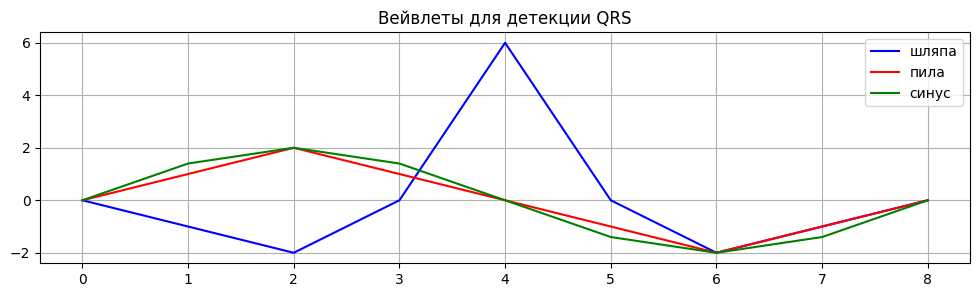

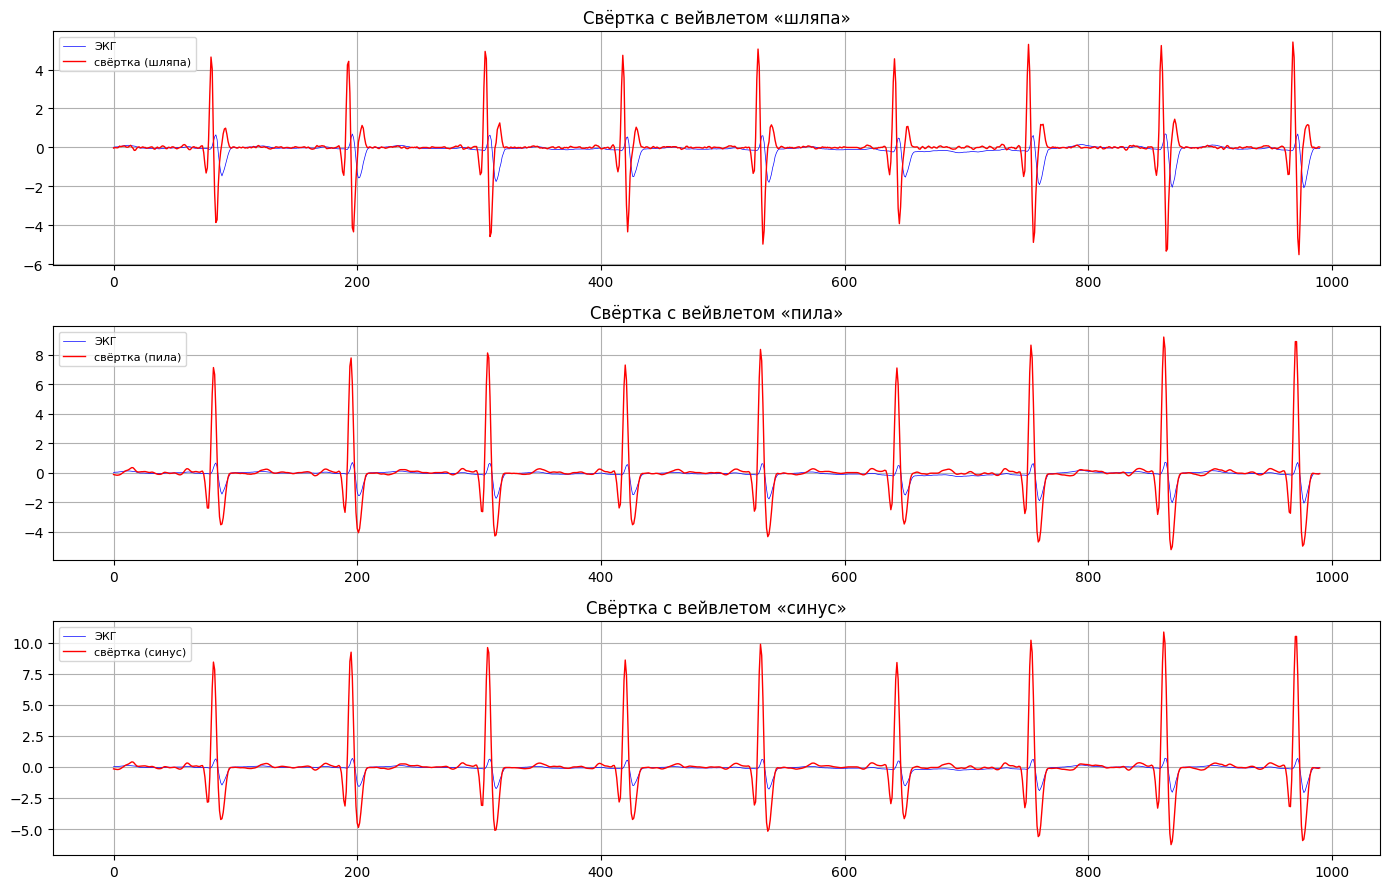

Обнаружено R-зубцов: 9
Средняя ЧСС: 108.1 уд/мин


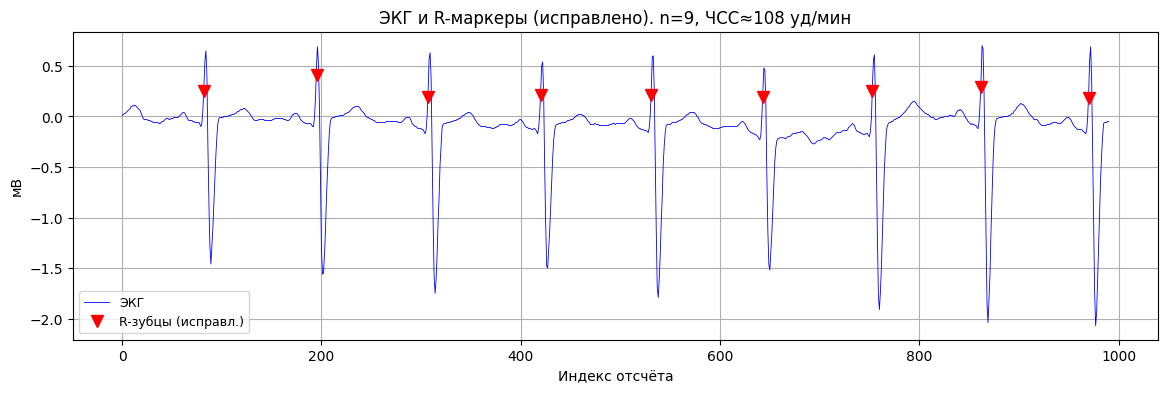

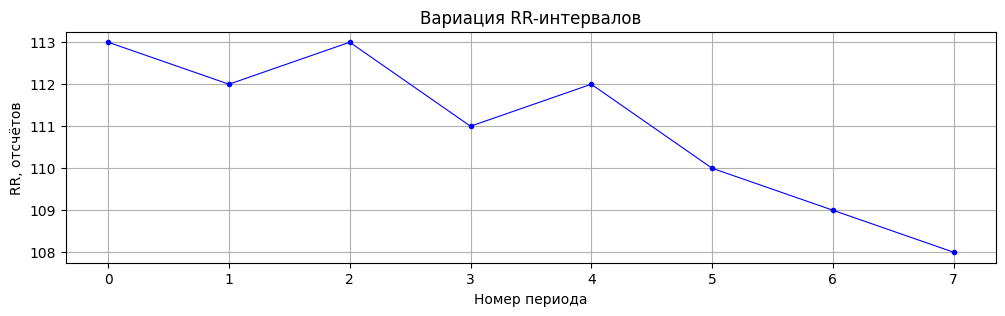

In [ ]:
import numpy as np

def read_edf_channel(fid, channel=0):
    """
    Читает один канал из EDF/EDF+ файла РОХМИНЭ.

    Параметры:
        fid     : str — путь к EDF-файлу
        channel : int — индекс канала (0-based, 0=V2-Ref, 1=V5-Ref, 2=avF-Ref)

    Возвращает:
        data_s  : list[float] — сигнал в мВ
        fs      : float — частота дискретизации, Гц
        meta    : dict — метаданные (patientID, startdate, starttime, labels, ...)
    """
    with open(fid, 'rb') as f:
        # ── Общий заголовок (256 байт) ──────────────────────────────────────
        vers      = f.read(8).decode('utf-8').strip()
        patientID = f.read(80).decode('utf-8').strip()
        recordID  = f.read(80).decode('utf-8').strip()
        startdate = f.read(8).decode('utf-8').strip()
        starttime = f.read(8).decode('utf-8').strip()
        numBytes  = int(f.read(8).decode('utf-8').strip())
        reserved  = f.read(44).decode('utf-8').strip()
        numRec    = int(f.read(8).decode('utf-8').strip())
        duration  = float(f.read(8).decode('utf-8').strip())
        ns        = int(f.read(4).decode('utf-8').strip())

        # ── Сигнальный заголовок (256 × ns байт) ────────────────────────────
        label      = [f.read(16).decode('utf-8').strip() for _ in range(ns)]
        transducer = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        units      = [f.read(8).decode('utf-8').strip()  for _ in range(ns)]
        physMin    = [float(f.read(8)) for _ in range(ns)]
        physMax    = [float(f.read(8)) for _ in range(ns)]
        digMin     = [float(f.read(8)) for _ in range(ns)]
        digMax     = [float(f.read(8)) for _ in range(ns)]
        prefilter  = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        samples    = [int(f.read(8))   for _ in range(ns)]
        reserv_ns  = [f.read(32).decode('utf-8').strip() for _ in range(ns)]

        # ── Масштабный коэффициент и смещение нуля ──────────────────────────
        scalefac = [(physMax[i]-physMin[i])/(digMax[i]-digMin[i])
                    if digMax[i] != digMin[i] else 1.0 for i in range(ns)]
        dc       = [physMax[i] - scalefac[i]*digMax[i] for i in range(ns)]

        fs = samples[channel] / duration   # Гц

        # ── Чтение данных: цикл по записям ─────────────────
        # для каждой из numRec записей читаем samples[ch] отсчётов канала
        data_s = []
        for rec in range(numRec):
            # Пропускаем данные каналов до нужного
            for ch_idx in range(ns):
                n = samples[ch_idx]
                raw_bytes = f.read(n * 2)
                if ch_idx == channel:
                    for i in range(n):
                        val = int.from_bytes(raw_bytes[i*2:(i+1)*2],
                                             byteorder='little', signed=True)
                        data_s.append(val * scalefac[channel] + dc[channel])

    meta = {'vers':vers,'patientID':patientID,'recordID':recordID,
            'startdate':startdate,'starttime':starttime,'numBytes':numBytes,
            'numRec':numRec,'duration':duration,'ns':ns,'labels':label,
            'units':units,'samples':samples,'fs':fs}
    return data_s, fs, meta

# ── Чтение файла ────────────────────────────────────────────────────────────
# В Colab: замените путь на имя загруженного файла
# from google.colab import files
# uploaded = files.upload()
# fid = list(uploaded.keys())[0]

fid = 'gusa.edf'   # <-- укажите путь к EDF-файлу
data_s, fs, meta = read_edf_channel(fid, channel=0)
print(f"Файл:       {fid}")
print(f"Пациент:    {meta['patientID']}")
print(f"Дата/Время: {meta['startdate']} {meta['starttime']}")
print(f"Каналы:     {meta['labels']}")
print(f"fs:         {fs} Гц")
print(f"Длина:      {len(data_s)} отсч. = {len(data_s)/fs/60:.1f} мин")
print(f"Диапазон:   {min(data_s):.3f} .. {max(data_s):.3f} {meta['units'][0]}")


# ─────────────────────────────────────────────────────────────────────────────
# ИДЕНТИФИКАЦИЯ R-ЗУБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

# Диапазон для анализа (в отсчётах)
range_beg = 0
range_end = min(1000, len(data_s))

# ── Вейвлеты ────────────────────────────────────────────────────────────────
wav1 = (0, -1, -2, 0, 6, 0, -2, -1, 0)   # «мексиканская шляпа»
wav2 = (0,  1,  2, 1, 0, -1, -2, -1, 0)  # «пила»
wav3 = (0, 1.4, 2, 1.4, 0, -1.4, -2, -1.4, 0)  # «синус»

x_wav = list(range(9))
plt.figure(figsize=(12, 3))
for wav, name, col in [(wav1,'шляпа','b'),(wav2,'пила','r'),(wav3,'синус','g')]:
    plt.plot(x_wav, wav, f'{col}-', lw=1.5, label=name)
plt.title('Вейвлеты для детекции QRS'); plt.legend(); plt.grid(True); plt.show()

# ── Свёртки ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, wav, name in zip(axes, [wav1, wav2, wav3], ['шляпа', 'пила', 'синус']):
    xs = list(range(range_beg, range_end - len(wav)))
    ws = []
    for kk in range(range_beg, range_end - len(wav)):
        integr = 0
        for ii in range(len(wav)):
            integr += data_s[kk + ii] * wav[ii]
        ws.append(integr)
    ax.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.5, label='ЭКГ')
    ax.plot(xs, ws, 'r-', lw=1.0, label=f'свёртка ({name})')
    ax.set_title(f'Свёртка с вейвлетом «{name}»'); ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

# ── Детекция R: синус-вейвлет + порог ────────────────────────────────────────
wav = wav3   # выбран синус как лучший для QRS
xs  = list(range(range_beg, range_end - len(wav)))
ws  = []
for kk in range(range_beg, range_end - len(wav)):
    integr = sum(data_s[kk + ii] * wav[ii] for ii in range(len(wav)))
    ws.append(integr)

# Порог: фиксированное значение (как в оригинале) или адаптивный mean+2σ
porog = 6   # фиксированный порог (оригинал)
# Адаптивный вариант (рекомендуется):
# import numpy as np; porog = np.mean(ws) + 2*np.std(ws)

ws_corr = [max(0, w - porog) for w in ws]

indR = []
yR   = []
ii = 1; tmp_max = 0; flag = False
while ii <= len(ws_corr) - 1:
    if ws_corr[ii] > tmp_max:
        tmp_max = ws_corr[ii]; flag = True
    else:
        if flag:
            indR.append(range_beg + ii - 1)
            yR.append(data_s[range_beg + ii - 1] * 0.8)
            tmp_max = ws_corr[ii]; flag = False
        else:
            tmp_max = ws_corr[ii]
    ii += 1

print(f"Обнаружено R-зубцов: {len(indR)}")
if len(indR) > 1:
    deltaR = [indR[i+1] - indR[i] for i in range(len(indR)-1)]
    bpm = 60 * fs / (sum(deltaR) / len(deltaR))
    print(f"Средняя ЧСС: {bpm:.1f} уд/мин")

# График: ЭКГ с R-маркерами
plt.figure(figsize=(14, 4))
plt.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.6, label='ЭКГ')
plt.plot(indR, yR, 'rv', ms=8, zorder=5, label='R-зубцы (исправл.)')
plt.xlabel('Индекс отсчёта'); plt.ylabel('мВ')
plt.title(f'ЭКГ и R-маркеры (исправлено). n={len(indR)}, ЧСС≈{bpm:.0f} уд/мин')
plt.legend(fontsize=9); plt.grid(True); plt.show()

# График RR-интервалов
if len(indR) > 1:
    plt.figure(figsize=(12, 3))
    plt.plot(deltaR, 'b-o', ms=3, lw=0.8)
    plt.xlabel('Номер периода'); plt.ylabel('RR, отсчётов')
    plt.title('Вариация RR-интервалов'); plt.grid(True); plt.show()

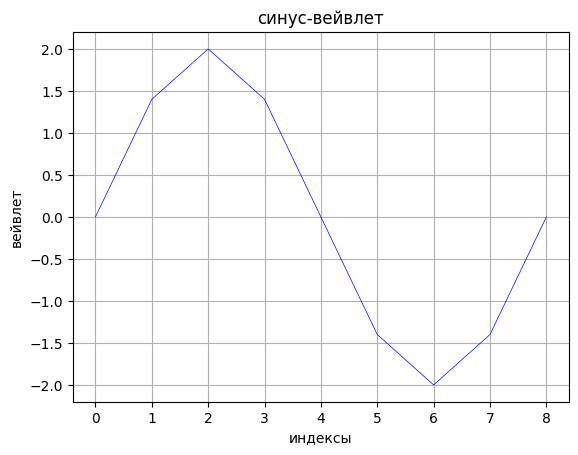

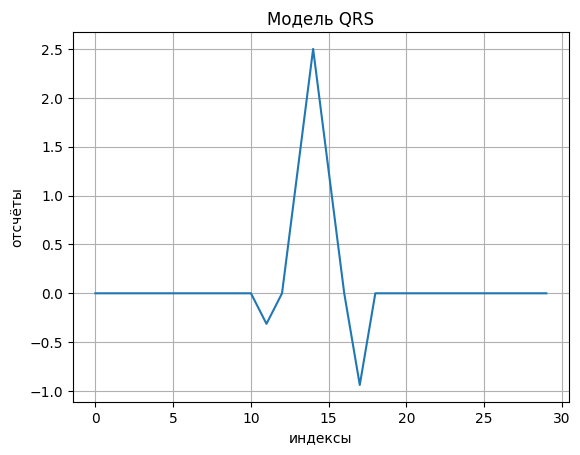

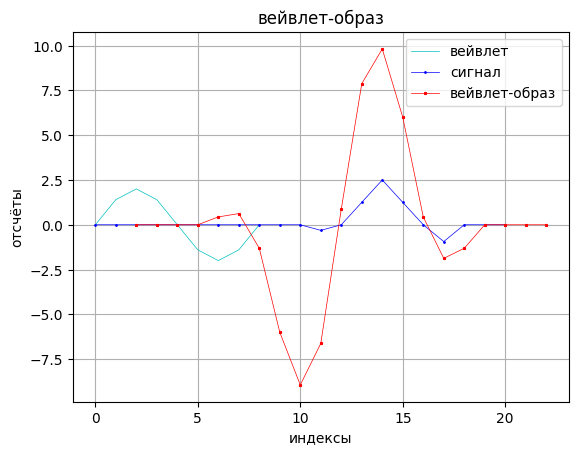

In [ ]:
#программа моделирования QRS комплекса и его вейвлет-образа
#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
import matplotlib.pyplot as plt
from math import pi as pi
import math

#проба генерации образов синус-вейвлета
#синус-вейвлет
wavsin=(0,1.4,2,1.4,0,-1.4,-2,-1.4,0)
x_sin=(0,1,2,3,4,5,6,7,8)

#график вейвлета
plt.plot(x_sin, wavsin,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('вейвлет') #Подпись для оси y
plt.title('синус-вейвлет') #Название
plt.grid(True)
plt.show()

#моделирование с изолированным QRS, по здоровой ЭКГ
#T(QRS)<=110 мс, дискретизация 5 мс, T(QRS)=22 интервала
#зубец R равен 6 интервалов, амплитуда R максимально
amR=2.5
#зубец Q равен 2 интервала, его амплитуда в минус
amQ=amR/4*0.5  #максимально R/4, может быть меньше
#зубец S равен 2 интервала, его амплитуда в минус
amS=amR/4*1.5  #максимально, может быть меньше

#генерация точек
y_mod=[]
#левый хвост
for ii in range(len(wavsin)+2):
    y_mod.append(0.0)
#Q
#y_mod.append(-amQ/2)
y_mod.append(-amQ)
#y_mod.append(-amQ/2)
y_mod.append(0.0)
#R
for ii in range (2):
    y_mod.append((ii+1)*amR/2)
for ii in range (2):
    y_mod.append((1-ii)*amR/2)
#S
#y_mod.append(-amS/2)
y_mod.append(-amS)
#y_mod.append(-amS/2)
y_mod.append(0.0)
#правый хвост
for ii in range(len(wavsin)+2):
    y_mod.append(0.0)

x_mod=[]
for ii in range (len(y_mod)):
    x_mod.append(ii)

plt.plot(x_mod, y_mod)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('Модель QRS') #Название
plt.grid(True)
plt.show()

#генерация свёртки
range_beg=0
range_end=len(y_mod)
xs=[]
xsc=[]
for ii in range (range_beg,range_end-len(wavsin)):
    xs.append(ii)
    xsc.append(ii+math.floor(len(wavsin)/2)-2)#смещение образа в индексах
#для совпадения максимумов
ws=[]
for kk in range (range_beg,range_end-len(wavsin)):
    integr=0
    for ii in range (len(wavsin)):#размер wavPT
        integr=integr+y_mod[kk+ii]*wavsin[ii]
    ws.append(integr)

#графики свёртки и исходного сигнала
plt.plot(x_sin, wavsin,'c-',xs,y_mod[range_beg:range_end-len(wavsin)],'b.-',xsc, ws,'r-*',linewidth = 0.5,markersize=2)
plt.grid(True)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('вейвлет-образ') #Название
plt.legend(['вейвлет','сигнал','вейвлет-образ'])
plt.show()

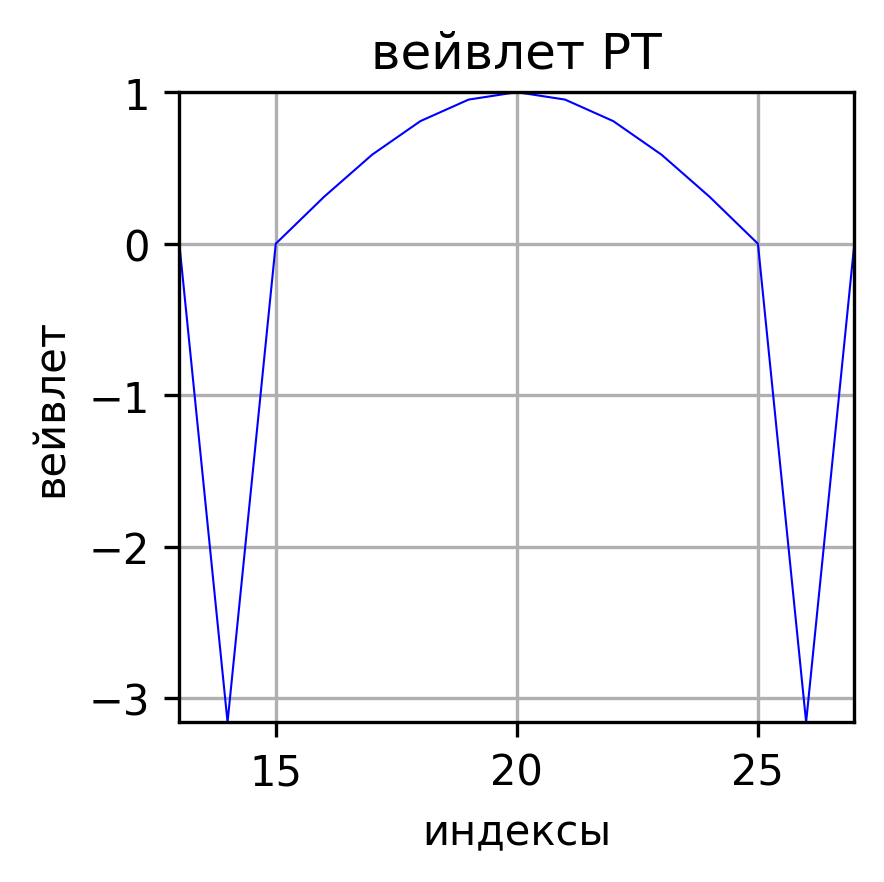

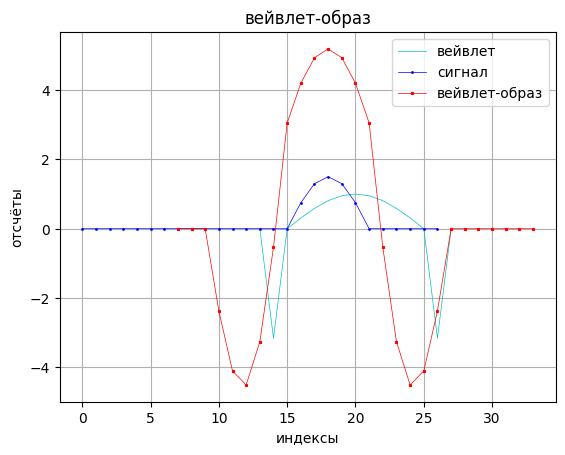

In [ ]:
#апробация вейвлета для идентификации Р и Т зубцов
#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from math import pi as pi
import math

#проба генерации образов положительной синус-полуволны

#задание диапазона индексов для полуволны, для симметрии нечётное число точек
x_len = 11
#генерация точек
y_sin=[]
x_sin=[]
for ii in range (x_len):
    x_sin.append(ii)
    y_sin.append(math.sin(pi*ii/(x_len-1)))

#вычисление площади полуволны
sq_w = 0
for ii in range(len(y_sin)-1):
    sq_w = sq_w + (y_sin[ii]+y_sin[ii+1])/2
#амплитуда минус-выбросов, каждый шириной 2 и площадью sq_w/2
a_neg = sq_w/2
#построение вейвлета
x_PT=[]
for ii in range (len(y_sin)+4):
    x_PT.append(ii+13)#13 задаёт смещение от 0 по Х
wavPT=[]
wavPT.append(0)
wavPT.append(-a_neg)
for ii in range (len(y_sin)):
    wavPT.append(y_sin[ii])
wavPT.append(-a_neg)
wavPT.append(0)
#график вейвлета
fig=plt.figure(figsize=(3.0,3.0),dpi=300.0)
ax=fig.add_axes([0.2,0.15,0.75,0.7])
ax.plot(x_PT, wavPT,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('вейвлет') #Подпись для оси y
plt.title('вейвлет РТ') #Название
plt.axis([x_PT[0],x_PT[len(x_PT)-1],min(wavPT),max(wavPT)])
plt.grid(True)
plt.show()
fig.savefig('proba.png')

#plt.plot(x_PT, wavPT,'b-', linewidth = 0.5,markersize=2)
#plt.xlabel('индексы') #Подпись для оси х
#plt.ylabel('вейвлет') #Подпись для оси y
#plt.title('вейвлет РТ') #Название
#plt.grid(True)
#plt.show()

#моделирование с изолированной полуволной
y_mod_len = 7
#генерация точек
y_mod_sin=[]
for ii in range (y_mod_len):
    y_mod_sin.append(1.5*math.sin(pi*ii/(y_mod_len-1)))


y_mod=[]
for ii in range (len(wavPT)):
    y_mod.append(0.0)
for ii in range (len(y_mod_sin)):
    y_mod.append(y_mod_sin[ii])
for ii in range (len(wavPT)+5):
    y_mod.append(0.0)
x_mod=[]
for ii in range (len(y_mod)):
    x_mod.append(ii)

#генерация свёртки
range_beg=0
range_end=len(y_mod)
xs=[]
xsc=[]
for ii in range (range_beg,range_end-len(wavPT)):
    xs.append(ii)
    xsc.append(ii+math.floor(len(wavPT)/2))#смещение образа в индексах
#для совпадения максимумов
ws=[]
for kk in range (range_beg,range_end-len(wavPT)):
    integr=0
    for ii in range (len(wavPT)):#размер wavPT
        integr=integr+y_mod[kk+ii]*wavPT[ii]
    ws.append(integr)

#графики свёртки и исходного сигнала
plt.plot(x_PT, wavPT,'c-',xs,y_mod[range_beg:range_end-len(wavPT)],'b.-',xsc, ws,'r-*',linewidth = 0.5,markersize=2)
plt.grid(True)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('вейвлет-образ') #Название
plt.legend(['вейвлет','сигнал','вейвлет-образ'])
plt.show()

Saving gusa.edf to gusa (1).edf


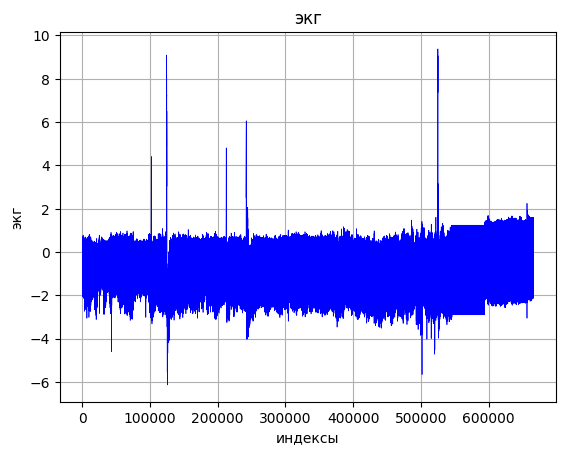

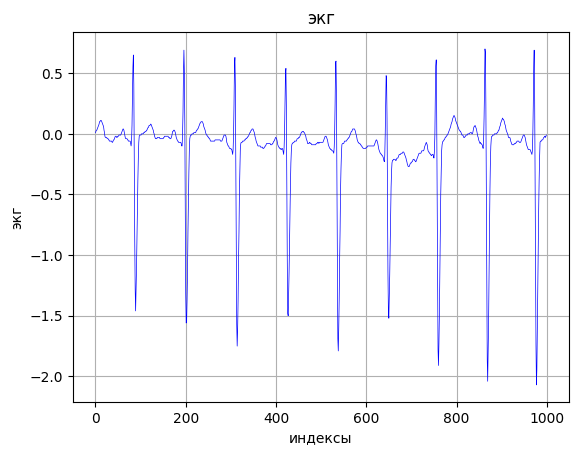

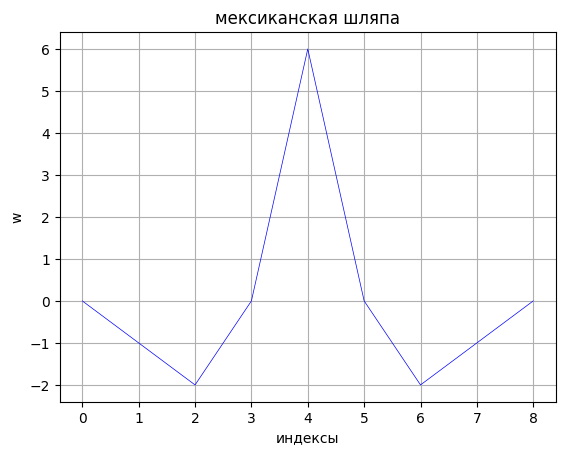

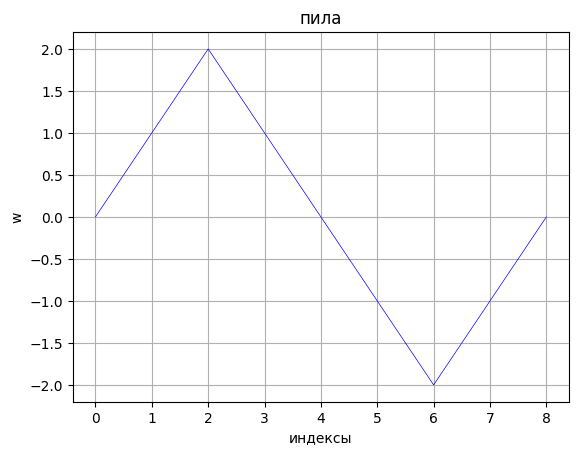

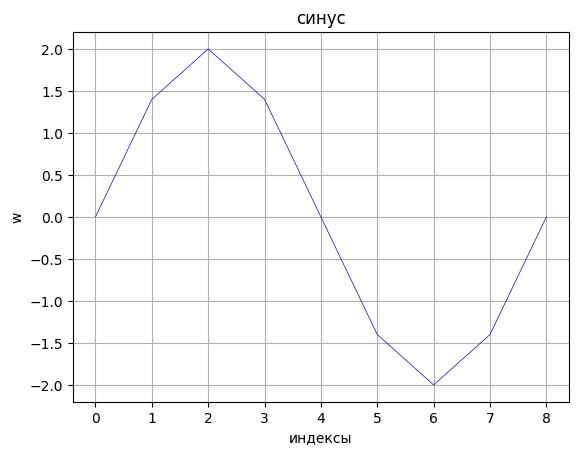

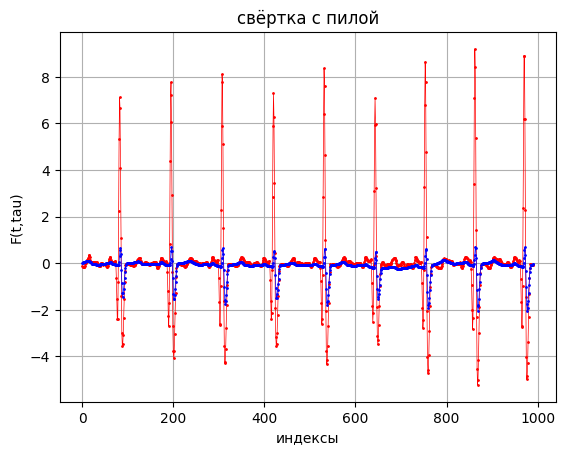

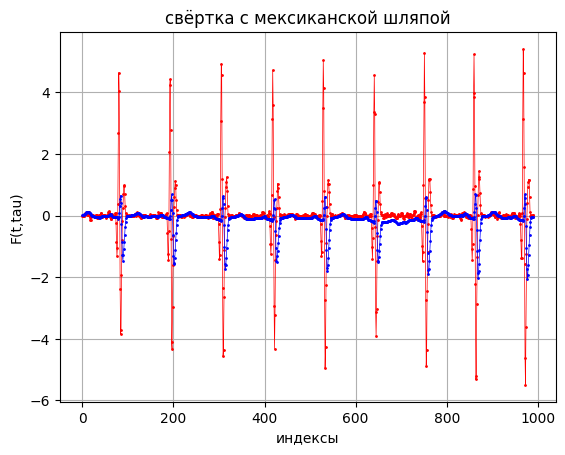

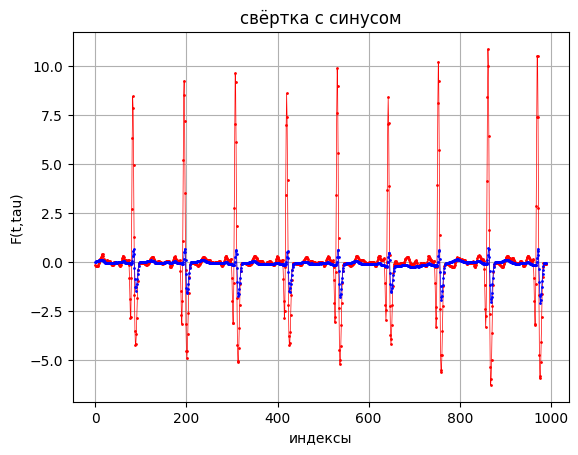

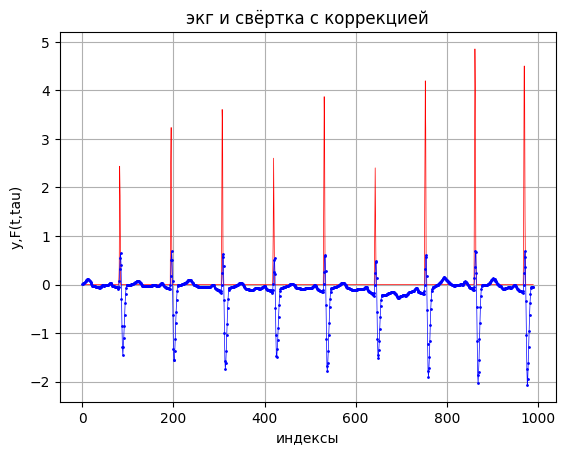

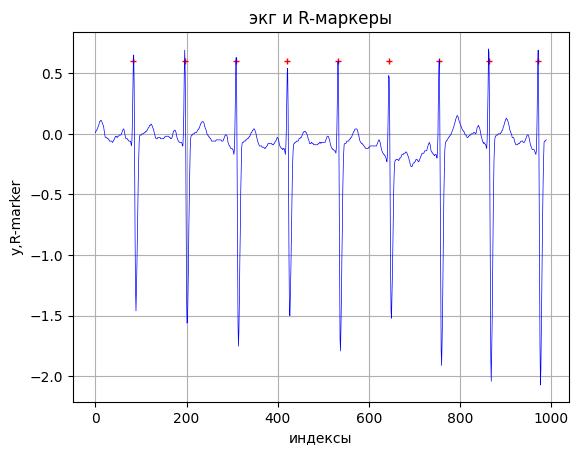

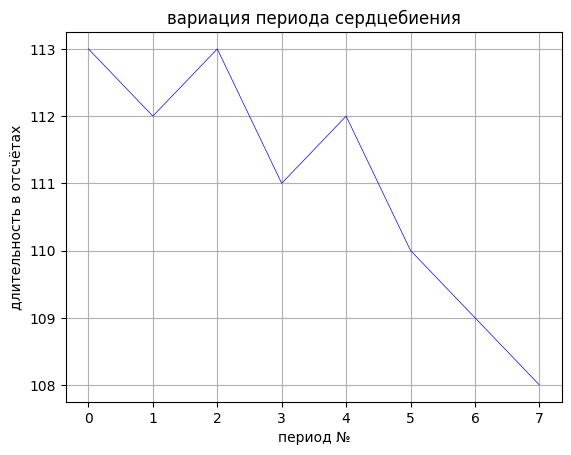

In [ ]:
#скрипт идентификации R зубцов, чтение файлов встроенное
#с вводом интервалов индексов вручную

#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
from google.colab import files # For file uploads
import matplotlib.pyplot as plt
from math import pi as pi
import math

#root = Tk()
#диалог открытия файла
#fid = filedialog.askopenfilename()

# To fix the Tkinter error in Colab, provide the file path directly.
# Replace '/path/to/your/file' with the actual path to your file after uploading.
#диалог открытия файла
uploaded = files.upload()

# Assuming only one file is uploaded, get the filename
fid = list(uploaded.keys())[0]

with open(fid,'rb') as f:
    #HEADER
    vers = float(f.read(8))#номер версии файла
    patientID = f.read(80).decode('utf-8')#ID пациента
    patientID = patientID.strip()#обрезание пробелов в начале и конце
    recordID = f.read(80).decode('utf-8')#ID записи
    recordID = recordID.strip()#обрезание пробелов в начале и конце
    startdate = f.read(8).decode('utf-8')#дата начала записи (dd.mm.yy)
    startdate = startdate.strip()#обрезание пробелов в начале и конце
    starttime = f.read(8).decode('utf-8')#время начала записи (hh.mm.ss)
    starttime = starttime.strip()#обрезание пробелов в начале и конце
    numBytes = int(f.read(8))#число байт
    reserved = f.read(44).decode('utf-8')#зарезервировано
    reserved = reserved.strip()#обрезание пробелов в начале и конце
    numRec = int(f.read(8))#число записей
    duration = float(f.read(8))#длительность записи
    ns = int(f.read(4))#число сигналов
    #создаётся пустой список меток
    label = []
    for ii in range(ns):#чтение меток = ответвлений
        label.append(f.read(16).decode('utf-8'))#добавление в список
        label[ii] = label[ii].strip()#обрезание пробелов в начале и конце
    #создаётся пустой список преобразователей? что это?
    transducer = []
    for ii in range(ns):#чтение преобразователей
        transducer.append(f.read(80).decode('utf-8'))#добавление в список
    #единицы измерения (мВ, мкВ, любые другие)
    units = []
    for ii in range(ns):#чтение
        units.append(f.read(8).decode('utf-8'))#добавление в список
        units[ii] = units[ii].strip()#обрезание пробелов в начале и конце
    #минимальное значение
    physicalMin = []
    for ii in range(ns):#чтение
        physicalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение
    physicalMax = []
    for ii in range(ns):#чтение
        physicalMax.append(float(f.read(8)))#добавление в список
    #минимальное значение в дискретах
    digitalMin = []
    for ii in range(ns):#чтение
        digitalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение в дискретах
    digitalMax = []
    for ii in range(ns):#чтение
        digitalMax.append(float(f.read(8)))#добавление в список
    #префильтр
    prefilter = []
    for ii in range(ns):#чтение
        prefilter.append(f.read(80).decode('utf-8'))#добавление в список
        prefilter[ii] = prefilter[ii].strip()#обрезание пробелов в начале и конце
    #отсчёты
    samples = []
    for ii in range(ns):#чтение
        samples.append(int(f.read(8)))#добавление в список
    #резервы сигналов
    reserv_ns = []
    for ii in range(ns):#чтение
        reserv_ns.append(f.read(32).decode('utf-8'))#добавление в список
        reserv_ns[ii] = reserv_ns[ii].strip()#обрезание пробелов в начале и конце
    #вычисление масштабного множителя для перевода дискрет в mV
    scalefac = []
    for ii in range(ns):
        sc_tmp = (physicalMax[ii] - physicalMin[ii])/(digitalMax[ii] - digitalMin[ii])
        scalefac.append(sc_tmp)
    #постоянная составляющая - корректор нуля
    dc = []
    for ii in range(ns):
        dc_tmp = physicalMax[ii] - scalefac[ii]*digitalMax[ii]
        dc.append(dc_tmp)
    #чтение данных:одно значение "целое со знаком" записано в 2 байта в порядке little
    #это когда последний байт знаковый. Соответственно этому задаются параметры метода
    #int.from_bytes - чтение 2 байт, byteorder='little',signed=True
    #ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ
    data_s = []
    for ii in range (samples[0]):
        data_tmp =  int.from_bytes(f.read(2),byteorder='little',signed=True)
        data_s.append(data_tmp*scalefac[0]+dc[0])
#ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ

#задание диапазона индексов  для всей записи
xt = samples[0];
#построение обзорного графика
x=[]
for ii in range (xt):
    x.append(ii)

#построение графика 1-го сигнала
plt.plot(x, data_s,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#список диапазона индексов
#range_ind=[0,0]
#
# Removed Tkinter dialogs for index input
# root = Tk()
# root.withdraw()
# showinfo(title='цикл ввода диапазона индексов',
#          message='ввод [нач.,кон.], выхода из цикла [0,0]')

#цикл ввода индексов
# while True:
#     root = Tk()
#     root.withdraw()
#     tmp_beg = int(simpledialog.askstring(title='',
#                                   prompt='начальный индекс'))
#     root = Tk()
#     root.withdraw()
#     tmp_end = int(simpledialog.askstring(title='',
#                                   prompt='конечный индекс'))

#     if tmp_beg >= tmp_end:
#          break
#     range_beg = tmp_beg
#     range_end = tmp_end

# To fix the Tkinter error in Colab, provide the range directly.
# Replace the values with your desired range.
range_beg = 0
range_end = 1000 # Example range

#построение обзорного графика
x=[]
for ii in range (range_beg,range_end):
    x.append(ii)

#построение обзорного графика сигнала
plt.plot(x, data_s[range_beg:range_end],'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#часть 2 - выделение QRS комплексов
#вейвлет
wav1=(0,-1,-2,0,6,0,-2,-1,0)#шляпа
wav2=(0,1,2,1,0,-1,-2,-1,0)#пила
wav3=(0,1.4,2,1.4,0,-1.4,-2,-1.4,0)#синус

x_wav=[]
for ii in range (9):
    x_wav.append(ii)

#применённые вейвлеты
plt.plot(x_wav, wav1,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('мексиканская шляпа') #Название
plt.grid(True)
plt.show()

plt.plot(x_wav, wav2,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('пила') #Название
plt.grid(True)
plt.show()

plt.plot(x_wav, wav3,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('w') #Подпись для оси y
plt.title('синус') #Название
plt.grid(True)
plt.show()

#генерация свёртки и построение графиков
#пила
xs=[]
for ii in range (range_beg,range_end-len(wav2)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav2)):
    integr=0
    for ii in range (len(wav2)):#размер wav2
        integr=integr+data_s[kk+ii]*wav2[ii]
    ws.append(integr)

#построение вейвлет-образа с пилой
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav2)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с пилой') #Название
plt.grid(True)
plt.show()

#шляпа
xs=[]
for ii in range (range_beg,range_end-len(wav1)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav1)):
    integr=0
    for ii in range (len(wav3)):#размер wav1
        integr=integr+data_s[kk+ii]*wav1[ii]
    ws.append(integr)

#построение вейвлет-образа с шляпой
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav1)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с мексиканской шляпой') #Название
plt.grid(True)
plt.show()

#синус
xs=[]
for ii in range (range_beg,range_end-len(wav3)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav3)):
    integr=0
    for ii in range (len(wav3)):#размер wav3
        integr=integr+data_s[kk+ii]*wav3[ii]
    ws.append(integr)

#построение вейвлет-образа
plt.plot(xs, ws,'r.-',xs,data_s[range_beg:range_end-len(wav3)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('F(t,tau)') #Подпись для оси y
plt.title('свёртка с синусом') #Название
plt.grid(True)
plt.show()


#коррекция вейвлет-образа - обнуление всего что меньше порога
porog = 6
for ii in range (len(ws)):
    if ws[ii]-porog < 0 : ws[ii]=0
    else : ws[ii]=ws[ii]-porog

#графики свёртки и исходного сигнала
plt.plot(xs, ws,'r-',xs,data_s[range_beg:range_end-len(wav3)],'b.-',linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y,F(t,tau)') #Подпись для оси y
plt.title('экг и свёртка с коррекцией') #Название
plt.grid(True)
plt.show()

#вычисление индексов R зубцов в отдельный список
indR=[]
yR=[]
kk=0 #счётчик indR
ii=1 #счётчик ws
tmp_max=0
flag=False

while ii <= len(ws)-1:
    if ws[ii]>tmp_max:#путь к максимуму
        tmp_max=ws[ii]
        flag=True
    else:#здесь начало падения, фиксация R
        if flag:
            indR.append(range_beg+ii) #коррекция вершины
            yR.append(0.6)#ординаты отображаемых точек R
            tmp_max=ws[ii]
            flag=False
            kk=kk+1
        else:tmp_max=ws[ii]#это путь к нулю
    ii=ii+1
#график исходного сигнала с отметками R зубцов
plt.plot(indR,yR,'+r',xs,data_s[range_beg:range_end-len(wav3)],'b-',linewidth = 0.5,markersize=5)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y,R-marker') #Подпись для оси y
plt.title('экг и R-маркеры') #Название
plt.grid(True)
plt.show()

#график изменения периода сердечных сокращений
deltaR=[]
xR=[]
ii=0;
while ii < len(indR)-1:
    deltaR.append(indR[ii+1]-indR[ii])
    xR.append(ii)
    ii=ii+1
plt.plot(xR,deltaR,'b-',linewidth = 0.5,markersize=3)
plt.xlabel('период №') #Подпись для оси х
plt.ylabel('длительность в отсчётах') #Подпись для оси y
plt.title('вариация периода сердцебиения') #Название
plt.grid(True)
plt.show()

Saving gusa.edf to gusa (2).edf


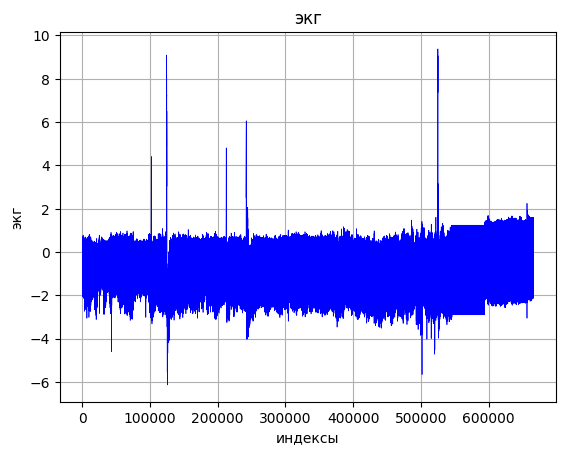

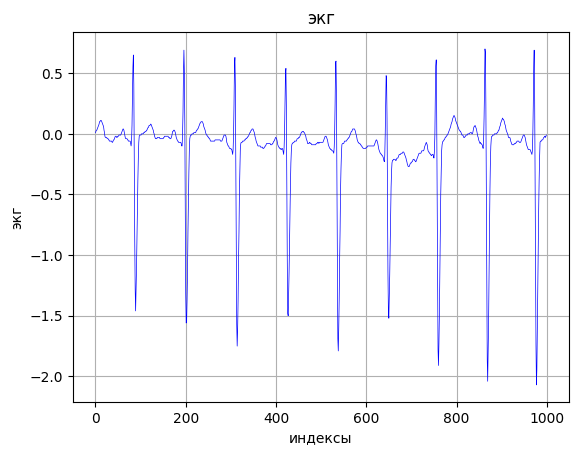

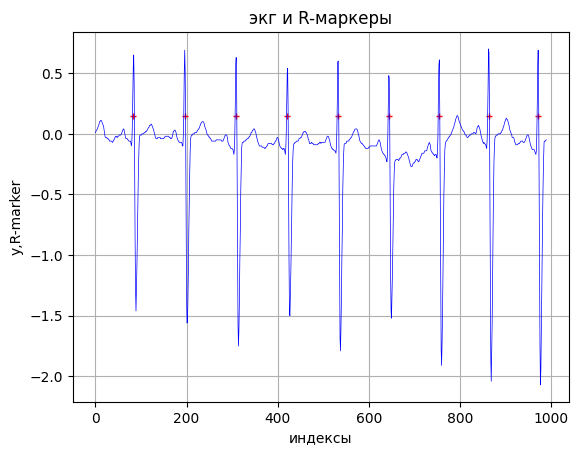

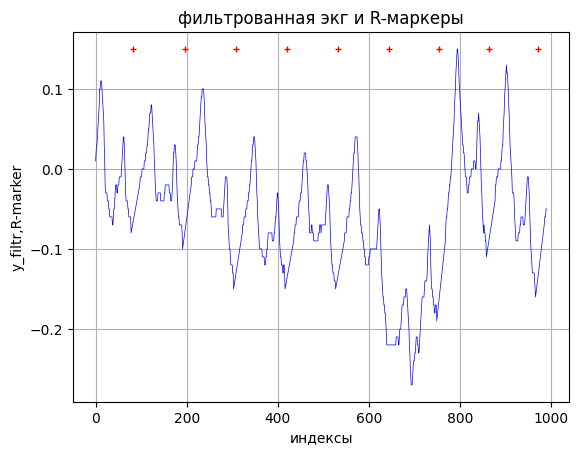

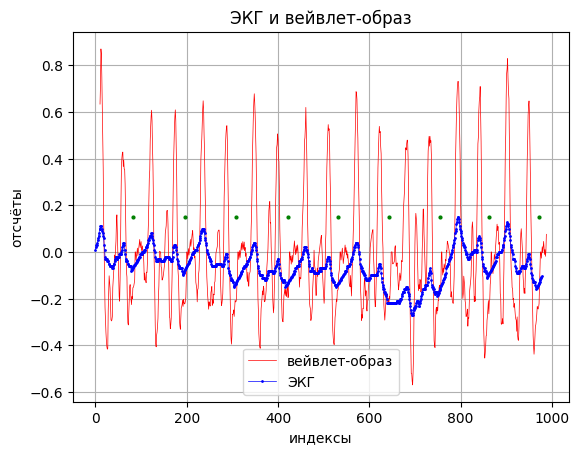

In [ ]:
#фильтрация QRS для РТ анализа
#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
from google.colab import files # For file uploads
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from math import pi as pi
import math

#root = Tk()
#диалог открытия файла
#fid = filedialog.askopenfilename()

# To fix the Tkinter error in Colab, provide the file path directly.
# Replace '/path/to/your/file' with the actual path to your file after uploading.
#диалог открытия файла
uploaded = files.upload()

# Assuming only one file is uploaded, get the filename
fid = list(uploaded.keys())[0]

with open(fid,'rb') as f:
    #HEADER
    vers = float(f.read(8))#номер версии файла
    patientID = f.read(80).decode('utf-8')#ID пациента
    patientID = patientID.strip()#обрезание пробелов в начале и конце
    recordID = f.read(80).decode('utf-8')#ID записи
    recordID = recordID.strip()#обрезание пробелов в начале и конце
    startdate = f.read(8).decode('utf-8')#дата начала записи (dd.mm.yy)
    startdate = startdate.strip()#обрезание пробелов в начале и конце
    starttime = f.read(8).decode('utf-8')#время начала записи (hh.mm.ss)
    starttime = starttime.strip()#обрезание пробелов в начале и конце
    numBytes = int(f.read(8))#число байт
    reserved = f.read(44).decode('utf-8')#зарезервировано
    reserved = reserved.strip()#обрезание пробелов в начале и конце
    numRec = int(f.read(8))#число записей
    duration = float(f.read(8))#длительность записи
    ns = int(f.read(4))#число сигналов
    #создаётся пустой список меток
    label = []
    for ii in range(ns):#чтение меток = ответвлений
        label.append(f.read(16).decode('utf-8'))#добавление в список
        label[ii] = label[ii].strip()#обрезание пробелов в начале и конце
    #создаётся пустой список преобразователей? что это?
    transducer = []
    for ii in range(ns):#чтение преобразователей
        transducer.append(f.read(80).decode('utf-8'))#добавление в список
    #единицы измерения (мВ, мкВ, любые другие)
    units = []
    for ii in range(ns):#чтение
        units.append(f.read(8).decode('utf-8'))#добавление в список
        units[ii] = units[ii].strip()#обрезание пробелов в начале и конце
    #минимальное значение
    physicalMin = []
    for ii in range(ns):#чтение
        physicalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение
    physicalMax = []
    for ii in range(ns):#чтение
        physicalMax.append(float(f.read(8)))#добавление в список
    #минимальное значение в дискретах
    digitalMin = []
    for ii in range(ns):#чтение
        digitalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение в дискретах
    digitalMax = []
    for ii in range(ns):#чтение
        digitalMax.append(float(f.read(8)))#добавление в список
    #префильтр
    prefilter = []
    for ii in range(ns):#чтение
        prefilter.append(f.read(80).decode('utf-8'))#добавление в список
        prefilter[ii] = prefilter[ii].strip()#обрезание пробелов в начале и конце
    #отсчёты
    samples = []
    for ii in range(ns):#чтение
        samples.append(int(f.read(8)))#добавление в список
    #резервы сигналов
    reserv_ns = []
    for ii in range(ns):#чтение
        reserv_ns.append(f.read(32).decode('utf-8'))#добавление в список
        reserv_ns[ii] = reserv_ns[ii].strip()#обрезание пробелов в начале и конце
    #вычисление масштабного множителя для перевода дискрет в mV
    scalefac = []
    for ii in range(ns):
        sc_tmp = (physicalMax[ii] - physicalMin[ii])/(digitalMax[ii] - digitalMin[ii])
        scalefac.append(sc_tmp)
    #постоянная составляющая - корректор нуля
    dc = []
    for ii in range(ns):
        dc_tmp = physicalMax[ii] - scalefac[ii]*digitalMax[ii]
        dc.append(dc_tmp)
    #чтение данных:одно значение "целое со знаком" записано в 2 байта в порядке little
    #это когда последний байт знаковый. Соответственно этому задаются параметры метода
    #int.from_bytes - чтение 2 байт, byteorder='little',signed=True
    #ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ
    data_s = []
    for ii in range (samples[0]):
        data_tmp =  int.from_bytes(f.read(2),byteorder='little',signed=True)
        data_s.append(data_tmp*scalefac[0]+dc[0])
#ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ

#задание диапазона индексов  для всей записи
xt = samples[0];
#построение обзорного графика
x=[]
for ii in range (xt):
    x.append(ii)

#построение графика 1-го сигнала
plt.plot(x, data_s,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#список диапазона индексов
#range_ind=[0,0]
#
# Removed Tkinter dialogs for index input
# root = Tk()
# root.withdraw()
# showinfo(title='цикл ввода диапазона индексов',
#          message='ввод [нач.,кон.], выхода из цикла [0,0]')

#цикл ввода индексов
# while True:
#     root = Tk()
#     root.withdraw()
#     tmp_beg = int(simpledialog.askstring(title='',
#                                   prompt='начальный индекс'))
#     root = Tk()
#     root.withdraw()
#     tmp_end = int(simpledialog.askstring(title='',
#                                   prompt='конечный индекс'))

#     if tmp_beg >= tmp_end:
#          break
#     range_beg = tmp_beg
#     range_end = tmp_end

# To fix the Tkinter error in Colab, provide the range directly.
# Replace the values with your desired range.
range_beg = 0
range_end = 1000 # Example range


#построение обзорного графика
x=[]
for ii in range (range_beg,range_end):
    x.append(ii)

#построение обзорного графика сигнала
plt.plot(x, data_s[range_beg:range_end],'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('экг') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

data_f=data_s
#часть 2 - выделение QRS комплексов
#вейвлет
wav=(0,1.4,2,1.4,0,-1.4,-2,-1.4,0)#синус

x_wav=[]
for ii in range (9):
    x_wav.append(ii)

#применённые вейвлеты
#plt.plot(x_wav, wav,'b-', linewidth = 0.5,markersize=2)
#plt.xlabel('индексы') #Подпись для оси х
#plt.ylabel('w') #Подпись для оси y
#plt.title('синус') #Название
#plt.grid(True)
#plt.show()

#генерация свёртки и построение графика
#синус
xs=[]
for ii in range (range_beg,range_end-len(wav)):
    xs.append(ii)

ws=[]
for kk in range (range_beg,range_end-len(wav)):
    integr=0
    for ii in range (len(wav)):#размер wav3
        integr=integr+data_s[kk+ii]*wav[ii]
    ws.append(integr)

#коррекция вейвлет-образа - обнуление всего что меньше порога
porog = 6
for ii in range (len(ws)):
    if ws[ii]-porog < 0 : ws[ii]=0
    else : ws[ii]=ws[ii]-porog

#вычисление индексов R зубцов в отдельный список
indR=[]
yR=[]
kk=0 #счётчик indR
ii=1 #счётчик ws
tmp_max=0
flag=False

while ii <= len(ws)-1:
    if ws[ii]>tmp_max:#путь к максимуму
        tmp_max=ws[ii]
        flag=True
    else:#здесь начало падения, фиксация R
        if flag:
            indR.append(range_beg+ii) #коррекция вершины
            yR.append(0.15)#ординаты отображаемых точек R
            tmp_max=ws[ii]
            flag=False
            kk=kk+1
        else:tmp_max=ws[ii]#это путь к нулю
    ii=ii+1
#график исходного сигнала с отметками R зубцов
plt.plot(indR,yR,'+r',xs,data_s[range_beg:range_end-len(wav)],'b-',linewidth = 0.5,markersize=5)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y,R-marker') #Подпись для оси y
plt.title('экг и R-маркеры') #Название
plt.grid(True)
plt.show()

#процедура фильтрации
for ii in range (len(indR)):
    if indR[ii]-math.ceil(len(wav)/2)<0:
        jleft = 0
        jrigth = indR[ii]+ math.ceil(3*len(wav)/2)
    elif indR[ii]+math.ceil(3*len(wav)/2)>len(data_s):
        jleft = indR[ii]-math.ceil(len(wav)/2)
        jrigth = len(data_s)-1
    else:
        jleft = indR[ii]-math.ceil(len(wav)/2)
        jrigth = indR[ii]+ math.ceil(3*len(wav)/2)
    #угол наклона
    k_a = (data_s[jrigth] - data_s[jleft])/(jrigth-jleft)
    for jj in range(jleft,jrigth):#постороение прямой
        data_f[jj]= data_s[jleft]+(jj-jleft)*k_a

#контроль
plt.plot(indR,yR,'+r',xs,data_f[range_beg:range_end-len(wav)],'b-',linewidth = 0.5,markersize=5)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('y_filtr,R-marker') #Подпись для оси y
plt.title('фильтрованная экг и R-маркеры') #Название
plt.grid(True)
plt.show()

#PT анализ
#часть 2 - выделение PT комплексов
#вейвлет
#задание диапазона индексов для полуволны, для симметрии нечётное число точек
x_len = 17 #27

#генерация точек
y_sin=[]
x_sin=[]
for ii in range (x_len):
    x_sin.append(ii)
    y_sin.append(math.sin(pi*ii/(x_len-1)))

#вычисление площади полуволны
sq_w = 0
for ii in range(len(y_sin)-1):
    sq_w = sq_w + (y_sin[ii]+y_sin[ii+1])/2
#амплитуда минус-выбросов, каждый шириной 2 и площадью sq_w/2
a_neg = sq_w/2
#построение вейвлета
x_PT=[]
for ii in range (len(y_sin)+4):
    x_PT.append(ii)
wavPT=[]
wavPT.append(0)
wavPT.append(-a_neg)
for ii in range (len(y_sin)):
    wavPT.append(y_sin[ii])
wavPT.append(-a_neg)
wavPT.append(0)
#график вейвлета
#plt.plot(x_PT, wavPT,'b-', linewidth = 0.5,markersize=2)
#plt.xlabel('индексы') #Подпись для оси х
#plt.ylabel('вейвлет') #Подпись для оси y
#plt.title('вейвлет РТ') #Название
#plt.grid(True)
#plt.show()


#генерация свёртки
#range_beg=0
#range_end=len(y_mod)
xs=[]
xsc=[]
for ii in range (range_beg,range_end-len(wavPT)):
    xs.append(ii)
    xsc.append(ii+math.floor(len(wavPT)/2))

ws=[]
for kk in range (range_beg,range_end-len(wavPT)):
    integr=0
    for ii in range (len(wavPT)):#размер wavPT
        integr=integr+data_f[kk+ii]*wavPT[ii]
    ws.append(integr)

#графики свёртки и исходного сигнала
plt.plot(xsc, ws,'r-',xs,data_f[range_beg:range_end-len(wavPT)],'b.-',\
         indR,yR,'og',linewidth = 0.5,markersize=2)
plt.grid(True)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('ЭКГ и вейвлет-образ') #Название
plt.legend(['вейвлет-образ','ЭКГ'])
plt.show()

Saving gusa.edf to gusa (3).edf


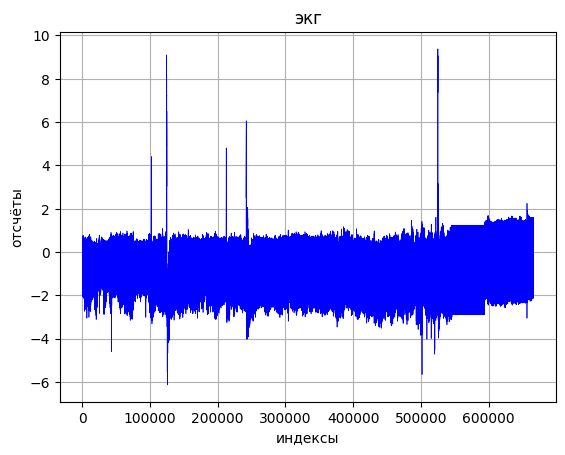

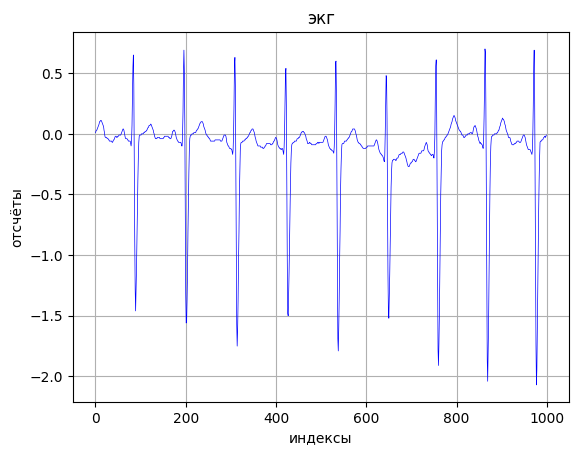

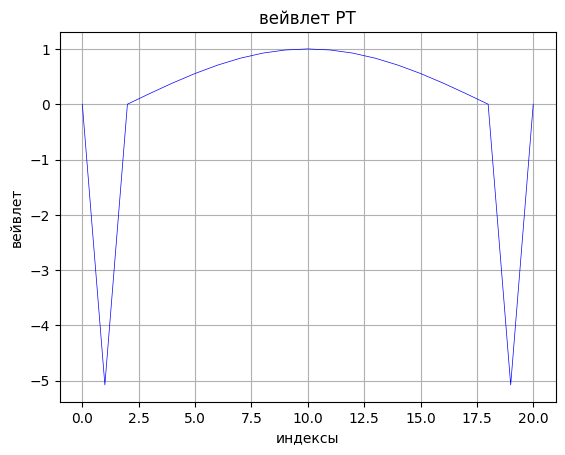

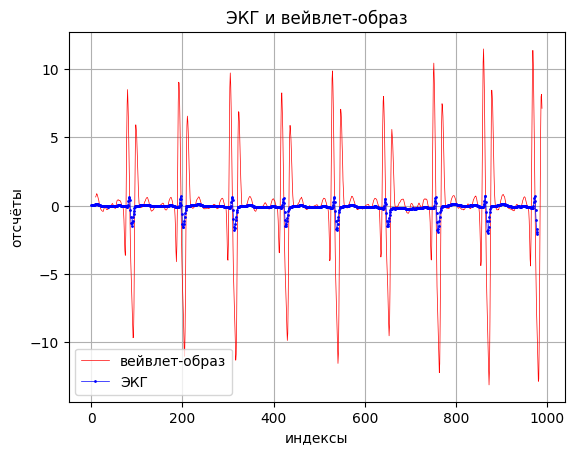

In [ ]:
#исследование возможностей разметки Р и Т зубцов
#библиотеки

#from tkinter import *
#from tkinter import filedialog #работа с файлами
#from tkinter import simpledialog #для ввода
#from tkinter.messagebox import showinfo #сообщения
#это для графиков
from google.colab import files # For file uploads
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from math import pi as pi
import math

#root = Tk()
#диалог открытия файла
#fid = filedialog.askopenfilename()

# To fix the Tkinter error in Colab, provide the file path directly.
# Replace '/path/to/your/file' with the actual path to your file after uploading.
#диалог открытия файла
uploaded = files.upload()

# Assuming only one file is uploaded, get the filename
fid = list(uploaded.keys())[0]

with open(fid,'rb') as f:
    #HEADER
    vers = float(f.read(8))#номер версии файла
    patientID = f.read(80).decode('utf-8')#ID пациента
    patientID = patientID.strip()#обрезание пробелов в начале и конце
    recordID = f.read(80).decode('utf-8')#ID записи
    recordID = recordID.strip()#обрезание пробелов в начале и конце
    startdate = f.read(8).decode('utf-8')#дата начала записи (dd.mm.yy)
    startdate = startdate.strip()#обрезание пробелов в начале и конце
    starttime = f.read(8).decode('utf-8')#время начала записи (hh.mm.ss)
    starttime = starttime.strip()#обрезание пробелов в начале и конце
    numBytes = int(f.read(8))#число байт
    reserved = f.read(44).decode('utf-8')#зарезервировано
    reserved = reserved.strip()#обрезание пробелов в начале и конце
    numRec = int(f.read(8))#число записей
    duration = float(f.read(8))#длительность записи
    ns = int(f.read(4))#число сигналов
    #создаётся пустой список меток
    label = []
    for ii in range(ns):#чтение меток = ответвлений
        label.append(f.read(16).decode('utf-8'))#добавление в список
        label[ii] = label[ii].strip()#обрезание пробелов в начале и конце
    #создаётся пустой список преобразователей? что это?
    transducer = []
    for ii in range(ns):#чтение преобразователей
        transducer.append(f.read(80).decode('utf-8'))#добавление в список
    #единицы измерения (мВ, мкВ, любые другие)
    units = []
    for ii in range(ns):#чтение
        units.append(f.read(8).decode('utf-8'))#добавление в список
        units[ii] = units[ii].strip()#обрезание пробелов в начале и конце
    #минимальное значение
    physicalMin = []
    for ii in range(ns):#чтение
        physicalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение
    physicalMax = []
    for ii in range(ns):#чтение
        physicalMax.append(float(f.read(8)))#добавление в список
    #минимальное значение в дискретах
    digitalMin = []
    for ii in range(ns):#чтение
        digitalMin.append(float(f.read(8)))#добавление в список
    #максимальное значение в дискретах
    digitalMax = []
    for ii in range(ns):#чтение
        digitalMax.append(float(f.read(8)))#добавление в список
    #префильтр
    prefilter = []
    for ii in range(ns):#чтение
        prefilter.append(f.read(80).decode('utf-8'))#добавление в список
        prefilter[ii] = prefilter[ii].strip()#обрезание пробелов в начале и конце
    #отсчёты
    samples = []
    for ii in range(ns):#чтение
        samples.append(int(f.read(8)))#добавление в список
    #резервы сигналов
    reserv_ns = []
    for ii in range(ns):#чтение
        reserv_ns.append(f.read(32).decode('utf-8'))#добавление в список
        reserv_ns[ii] = reserv_ns[ii].strip()#обрезание пробелов в начале и конце
    #вычисление масштабного множителя для перевода дискрет в mV
    scalefac = []
    for ii in range(ns):
        sc_tmp = (physicalMax[ii] - physicalMin[ii])/(digitalMax[ii] - digitalMin[ii])
        scalefac.append(sc_tmp)
    #постоянная составляющая - корректор нуля
    dc = []
    for ii in range(ns):
        dc_tmp = physicalMax[ii] - scalefac[ii]*digitalMax[ii]
        dc.append(dc_tmp)
    #чтение данных:одно значение "целое со знаком" записано в 2 байта в порядке little
    #это когда последний байт знаковый. Соответственно этому задаются параметры метода
    #int.from_bytes - чтение 2 байт, byteorder='little',signed=True
    #ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ
    data_s = []
    for ii in range (samples[0]):
        data_tmp =  int.from_bytes(f.read(2),byteorder='little',signed=True)
        data_s.append(data_tmp*scalefac[0]+dc[0])
#ТУТ НУЖНО СДЕЛАТЬ ЦИКЛ ДЛЯ ВСЕХ СИГНАЛОВ

#задание диапазона индексов  для всей записи
xt = samples[0];
#построение обзорного графика
x=[]
for ii in range (xt):
    x.append(ii)

#построение графика 1-го сигнала
plt.plot(x, data_s,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#список диапазона индексов
#range_ind=[0,0]
#
#root = Tk()
#root.withdraw()
# showinfo(title='цикл ввода диапазона индексов',
#          message='ввод [нач.,кон.], выхода из цикла [0,0]')

#цикл ввода индексов
# while True:
#     root = Tk()
#     root.withdraw()
#     tmp_beg = int(simpledialog.askstring(title='',
#                                   prompt='начальный индекс'))
#     root = Tk()
#     root.withdraw()
#     tmp_end = int(simpledialog.askstring(title='',
#                                   prompt='конечный индекс'))

#     if tmp_beg >= tmp_end:
#          break
#     range_beg = tmp_beg
#     range_end = tmp_end

# To fix the Tkinter error in Colab, provide the range directly.
# Replace the values with your desired range.
range_beg = 0
range_end = 1000 # Example range


#построение обзорного графика
x=[]
for ii in range (range_beg,range_end):
    x.append(ii)

#построение обзорного графика сигнала
plt.plot(x, data_s[range_beg:range_end],'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('экг') #Название
plt.grid(True)
plt.show()

#часть 2 - выделение PT комплексов
#вейвлет
#задание диапазона индексов для полуволны, для симметрии нечётное число точек
x_len = 17 #27

#генерация точек
y_sin=[]
x_sin=[]
for ii in range (x_len):
    x_sin.append(ii)
    y_sin.append(math.sin(pi*ii/(x_len-1)))

#вычисление площади полуволны
sq_w = 0
for ii in range(len(y_sin)-1):
    sq_w = sq_w + (y_sin[ii]+y_sin[ii+1])/2
#амплитуда минус-выбросов, каждый шириной 2 и площадью sq_w/2
a_neg = sq_w/2
#построение вейвлета
x_PT=[]
for ii in range (len(y_sin)+4):
    x_PT.append(ii)
wavPT=[]
wavPT.append(0)
wavPT.append(-a_neg)
for ii in range (len(y_sin)):
    wavPT.append(y_sin[ii])
wavPT.append(-a_neg)
wavPT.append(0)
#график вейвлета
plt.plot(x_PT, wavPT,'b-', linewidth = 0.5,markersize=2)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('вейвлет') #Подпись для оси y
plt.title('вейвлет РТ') #Название
plt.grid(True)
plt.show()


#генерация свёртки
#range_beg=0
#range_end=len(y_mod)
xs=[]
xsc=[]
for ii in range (range_beg,range_end-len(wavPT)):
    xs.append(ii)
    xsc.append(ii+math.floor(len(wavPT)/2))

ws=[]
for kk in range (range_beg,range_end-len(wavPT)):
    integr=0
    for ii in range (len(wavPT)):#размер wavPT
        integr=integr+data_s[kk+ii]*wavPT[ii]
    ws.append(integr)

#коррекция вейвлет-образа - обнуление всего что меньше порога
#porog = 6
#for ii in range (len(ws)):
#    if ws[ii]-porog < 0 : ws[ii]=0
#    else : ws[ii]=ws[ii]-porog

#графики свёртки и исходного сигнала
plt.plot(xsc, ws,'r-',xs,data_s[range_beg:range_end-len(wavPT)],'b.-',linewidth = 0.5,markersize=2)
plt.grid(True)
plt.xlabel('индексы') #Подпись для оси х
plt.ylabel('отсчёты') #Подпись для оси y
plt.title('ЭКГ и вейвлет-образ') #Название
plt.legend(['вейвлет-образ','ЭКГ'])
plt.show()

Файл:       gusa.edf
Пациент:    _F_06.10.2014_
Дата/Время: 14.11.17 11.30.20
Каналы:     ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
fs:         200.0 Гц
Длина:      666000 отсч. = 55.5 мин
Диапазон:   -6.130 .. 9.380 mV


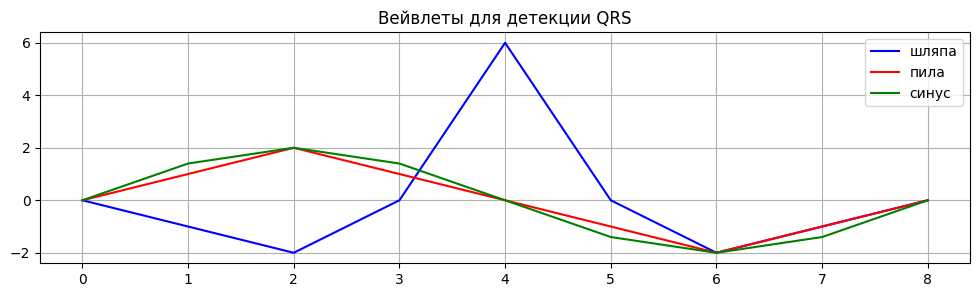

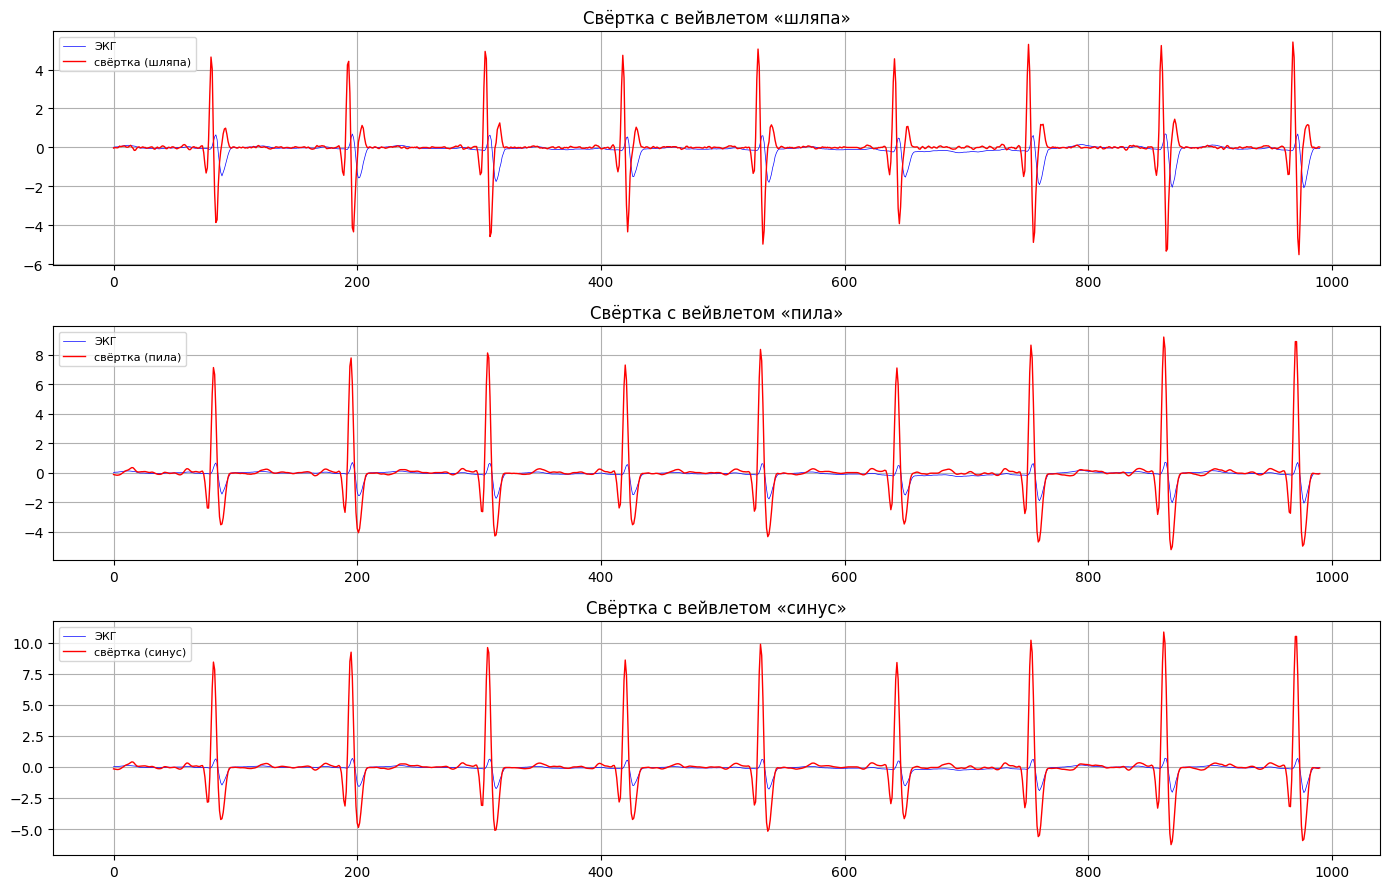

Обнаружено R-зубцов: 9
Средняя ЧСС: 108.1 уд/мин


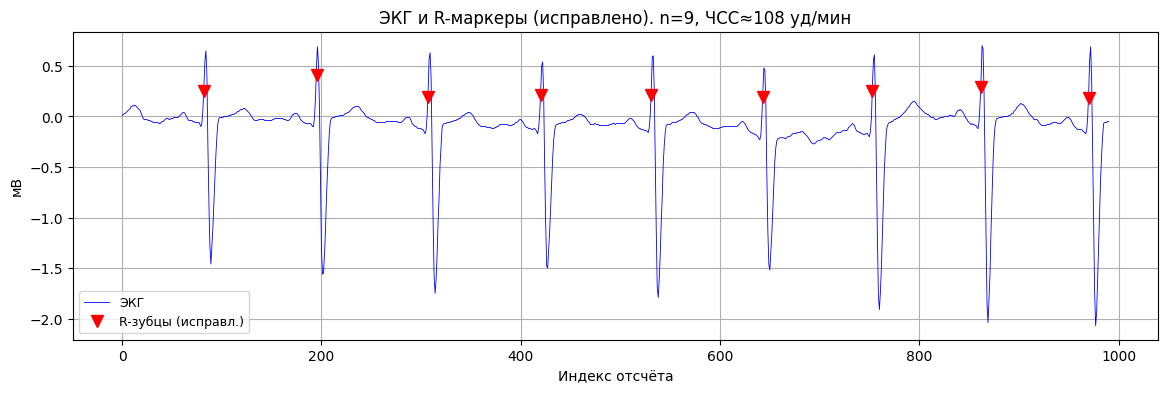

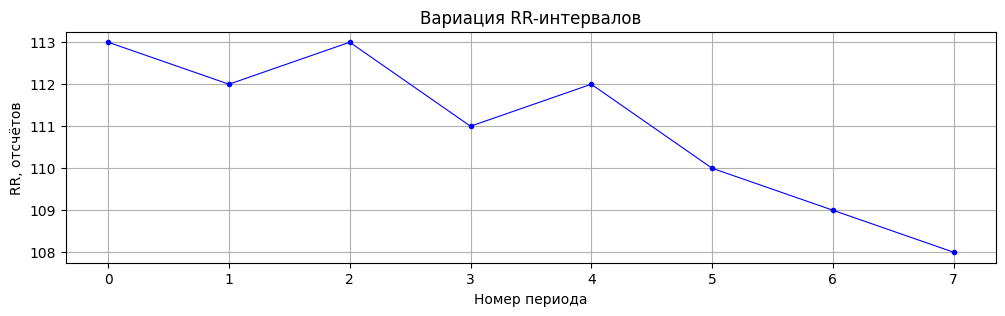

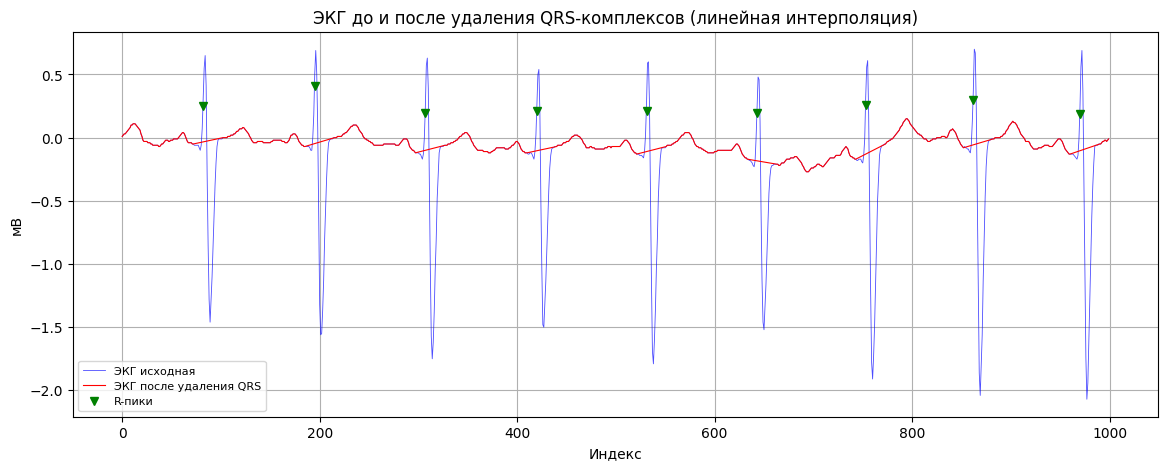

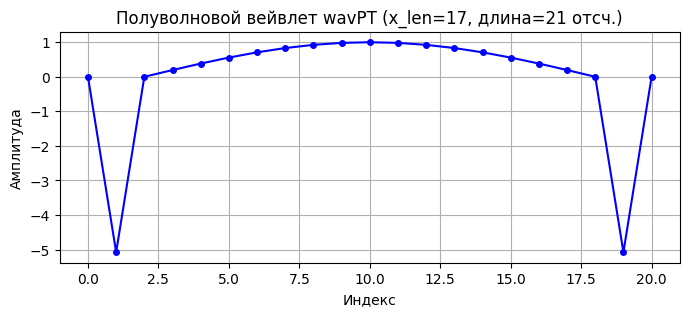

Порог wavPT: 0.2611


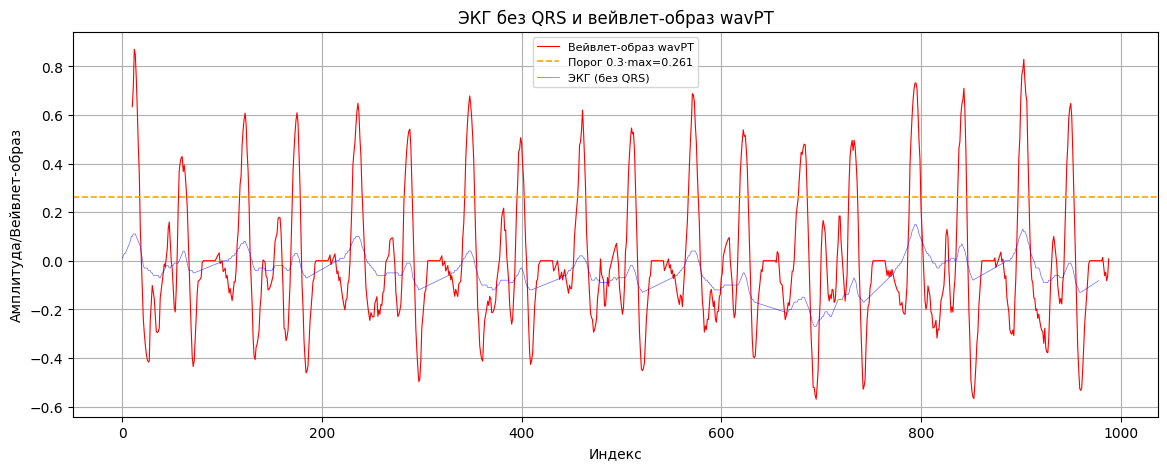

In [ ]:
import numpy as np

def read_edf_channel(fid, channel=0):
    """
    Читает один канал из EDF/EDF+ файла РОХМИНЭ.

    Параметры:
        fid     : str — путь к EDF-файлу
        channel : int — индекс канала (0-based, 0=V2-Ref, 1=V5-Ref, 2=avF-Ref)

    Возвращает:
        data_s  : list[float] — сигнал в мВ
        fs      : float — частота дискретизации, Гц
        meta    : dict — метаданные (patientID, startdate, starttime, labels, ...)
    """
    with open(fid, 'rb') as f:
        # ── Общий заголовок (256 байт) ──────────────────────────────────────
        vers      = f.read(8).decode('utf-8').strip()
        patientID = f.read(80).decode('utf-8').strip()
        recordID  = f.read(80).decode('utf-8').strip()
        startdate = f.read(8).decode('utf-8').strip()
        starttime = f.read(8).decode('utf-8').strip()
        numBytes  = int(f.read(8).decode('utf-8').strip())
        reserved  = f.read(44).decode('utf-8').strip()
        numRec    = int(f.read(8).decode('utf-8').strip())
        duration  = float(f.read(8).decode('utf-8').strip())
        ns        = int(f.read(4).decode('utf-8').strip())

        # ── Сигнальный заголовок (256 × ns байт) ────────────────────────────
        label      = [f.read(16).decode('utf-8').strip() for _ in range(ns)]
        transducer = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        units      = [f.read(8).decode('utf-8').strip()  for _ in range(ns)]
        physMin    = [float(f.read(8)) for _ in range(ns)]
        physMax    = [float(f.read(8)) for _ in range(ns)]
        digMin     = [float(f.read(8)) for _ in range(ns)]
        digMax     = [float(f.read(8)) for _ in range(ns)]
        prefilter  = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        samples    = [int(f.read(8))   for _ in range(ns)]
        reserv_ns  = [f.read(32).decode('utf-8').strip() for _ in range(ns)]

        # ── Масштабный коэффициент и смещение нуля ──────────────────────────
        scalefac = [(physMax[i]-physMin[i])/(digMax[i]-digMin[i])
                    if digMax[i] != digMin[i] else 1.0 for i in range(ns)]
        dc       = [physMax[i] - scalefac[i]*digMax[i] for i in range(ns)]

        fs = samples[channel] / duration   # Гц

        # ── Чтение данных: цикл по записям ─────────────────
        # для каждой из numRec записей читаем samples[ch] отсчётов канала
        data_s = []
        for rec in range(numRec):
            # Пропускаем данные каналов до нужного
            for ch_idx in range(ns):
                n = samples[ch_idx]
                raw_bytes = f.read(n * 2)
                if ch_idx == channel:
                    for i in range(n):
                        val = int.from_bytes(raw_bytes[i*2:(i+1)*2],
                                             byteorder='little', signed=True)
                        data_s.append(val * scalefac[channel] + dc[channel])

    meta = {'vers':vers,'patientID':patientID,'recordID':recordID,
            'startdate':startdate,'starttime':starttime,'numBytes':numBytes,
            'numRec':numRec,'duration':duration,'ns':ns,'labels':label,
            'units':units,'samples':samples,'fs':fs}
    return data_s, fs, meta

# ── Чтение файла ────────────────────────────────────────────────────────────
# В Colab: замените путь на имя загруженного файла
# from google.colab import files
# uploaded = files.upload()
# fid = list(uploaded.keys())[0]

fid = 'gusa.edf'   # <-- укажите путь к EDF-файлу
data_s, fs, meta = read_edf_channel(fid, channel=0)
print(f"Файл:       {fid}")
print(f"Пациент:    {meta['patientID']}")
print(f"Дата/Время: {meta['startdate']} {meta['starttime']}")
print(f"Каналы:     {meta['labels']}")
print(f"fs:         {fs} Гц")
print(f"Длина:      {len(data_s)} отсч. = {len(data_s)/fs/60:.1f} мин")
print(f"Диапазон:   {min(data_s):.3f} .. {max(data_s):.3f} {meta['units'][0]}")


# ─────────────────────────────────────────────────────────────────────────────
# ИДЕНТИФИКАЦИЯ R-ЗУБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

# Диапазон для анализа (в отсчётах)
range_beg = 0
range_end = min(1000, len(data_s))

# ── Вейвлеты ────────────────────────────────────────────────────────────────
wav1 = (0, -1, -2, 0, 6, 0, -2, -1, 0)   # «мексиканская шляпа»
wav2 = (0,  1,  2, 1, 0, -1, -2, -1, 0)  # «пила»
wav3 = (0, 1.4, 2, 1.4, 0, -1.4, -2, -1.4, 0)  # «синус»

x_wav = list(range(9))
plt.figure(figsize=(12, 3))
for wav, name, col in [(wav1,'шляпа','b'),(wav2,'пила','r'),(wav3,'синус','g')]:
    plt.plot(x_wav, wav, f'{col}-', lw=1.5, label=name)
plt.title('Вейвлеты для детекции QRS'); plt.legend(); plt.grid(True); plt.show()

# ── Свёртки ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, wav, name in zip(axes, [wav1, wav2, wav3], ['шляпа', 'пила', 'синус']):
    xs = list(range(range_beg, range_end - len(wav)))
    ws = []
    for kk in range(range_beg, range_end - len(wav)):
        integr = 0
        for ii in range(len(wav)):
            integr += data_s[kk + ii] * wav[ii]
        ws.append(integr)
    ax.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.5, label='ЭКГ')
    ax.plot(xs, ws, 'r-', lw=1.0, label=f'свёртка ({name})')
    ax.set_title(f'Свёртка с вейвлетом «{name}»'); ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

# ── Детекция R: синус-вейвлет + порог ────────────────────────────────────────
wav = wav3   # выбран синус как лучший для QRS
xs  = list(range(range_beg, range_end - len(wav)))
ws  = []
for kk in range(range_beg, range_end - len(wav)):
    integr = sum(data_s[kk + ii] * wav[ii] for ii in range(len(wav)))
    ws.append(integr)

# Порог: фиксированное значение (как в оригинале) или адаптивный mean+2σ
porog = 6   # фиксированный порог (оригинал)
# Адаптивный вариант (рекомендуется):
# import numpy as np; porog = np.mean(ws) + 2*np.std(ws)

ws_corr = [max(0, w - porog) for w in ws]

indR = []
yR   = []
ii = 1; tmp_max = 0; flag = False
while ii <= len(ws_corr) - 1:
    if ws_corr[ii] > tmp_max:
        tmp_max = ws_corr[ii]; flag = True
    else:
        if flag:
            indR.append(range_beg + ii - 1)  # ИСПРАВЛЕНО: ii-1, не ii
            yR.append(data_s[range_beg + ii - 1] * 0.8)
            tmp_max = ws_corr[ii]; flag = False
        else:
            tmp_max = ws_corr[ii]
    ii += 1

print(f"Обнаружено R-зубцов: {len(indR)}")
if len(indR) > 1:
    deltaR = [indR[i+1] - indR[i] for i in range(len(indR)-1)]
    bpm = 60 * fs / (sum(deltaR) / len(deltaR))
    print(f"Средняя ЧСС: {bpm:.1f} уд/мин")

# График: ЭКГ с R-маркерами
plt.figure(figsize=(14, 4))
plt.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.6, label='ЭКГ')
plt.plot(indR, yR, 'rv', ms=8, zorder=5, label='R-зубцы (исправл.)')
plt.xlabel('Индекс отсчёта'); plt.ylabel('мВ')
plt.title(f'ЭКГ и R-маркеры (исправлено). n={len(indR)}, ЧСС≈{bpm:.0f} уд/мин')
plt.legend(fontsize=9); plt.grid(True); plt.show()

# График RR-интервалов
if len(indR) > 1:
    plt.figure(figsize=(12, 3))
    plt.plot(deltaR, 'b-o', ms=3, lw=0.8)
    plt.xlabel('Номер периода'); plt.ylabel('RR, отсчётов')
    plt.title('Вариация RR-интервалов'); plt.grid(True); plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# ФИЛЬТРАЦИЯ QRS И ДЕТЕКЦИЯ P/T-ЗУБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

# ИСПРАВЛЕНИЕ №6: data_f должен быть КОПИЕЙ data_s, а не ссылкой!
# Оригинал: data_f = data_s  ← ОШИБКА: оба указывают на один объект
data_f = data_s.copy()        # ← ИСПРАВЛЕНО

# ── Детекция R (используются indR из предыдущей ячейки) ──────────────────────
# Если indR не определён — запустите сначала ячейку детекции R

# ── Процедура фильтрации QRS: замена интерполяцией ────────────────────────────
# Расширение окна вырезания QRS
#   Оригинал: jleft = R − ceil(len(wav)/2) = R − 5 отсч = 25 мс (слишком мало)
#             jrigth = R + ceil(3*len(wav)/2) = R + 14 отсч = 70 мс
#   Исправлено: ±50 мс слева, +100 мс справа (охватывает QRS 80–120 мс)
jleft_ms  = 50   # мс до R
jrigth_ms = 100  # мс после R
jleft_n   = int(jleft_ms  / 1000 * fs)   # отсчётов
jrigth_n  = int(jrigth_ms / 1000 * fs)   # отсчётов

for ii in range(len(indR)):
    jleft  = max(0, indR[ii] - jleft_n)
    jrigth = min(len(data_f) - 1, indR[ii] + jrigth_n)
    if jrigth - jleft < 2:
        continue
    # Линейная интерполяция между data_f[jleft] и data_f[jrigth]
    k_a = (data_f[jrigth] - data_f[jleft]) / (jrigth - jleft)
    for jj in range(jleft, jrigth):
        data_f[jj] = data_f[jleft] + (jj - jleft) * k_a
        # Здесь data_f изменяется, data_s — НЕТ (благодаря .copy())

# Контроль фильтрации
xs_plot = list(range(range_beg, range_end))
plt.figure(figsize=(14, 5))
plt.plot(xs_plot, data_s[range_beg:range_end], 'b-', lw=0.6, alpha=0.7, label='ЭКГ исходная')
plt.plot(xs_plot, data_f[range_beg:range_end], 'r-', lw=0.8, label='ЭКГ после удаления QRS')
plt.plot(indR, [data_s[r]*0.8 for r in indR if range_beg<=r<range_end],
         'gv', ms=6, zorder=5, label='R-пики')
plt.xlabel('Индекс'); plt.ylabel('мВ')
plt.title('ЭКГ до и после удаления QRS-комплексов (линейная интерполяция)')
plt.legend(fontsize=8); plt.grid(True); plt.show()

# ── Вейвлет PT ────────────────────────────────────────────────────────────────
x_len = 17   # точек положительного полупериода ≈ 85 мс при fs=200 Гц

y_sin = [math.sin(math.pi * ii / (x_len - 1)) for ii in range(x_len)]
sq_w  = sum((y_sin[ii] + y_sin[ii+1]) / 2 for ii in range(len(y_sin) - 1))
a_neg = sq_w / 2   # амплитуда отрицательных крыльев

wavPT = [0, -a_neg] + y_sin + [-a_neg, 0]
x_PT  = list(range(len(wavPT)))

plt.figure(figsize=(8, 3))
plt.plot(x_PT, wavPT, 'b-o', ms=4, lw=1.5)
plt.title(f'Полуволновой вейвлет wavPT (x_len={x_len}, длина={len(wavPT)} отсч.)')
plt.xlabel('Индекс'); plt.ylabel('Амплитуда'); plt.grid(True); plt.show()

# ── Вейвлет-образ для PT ──────────────────────────────────────────────────────
xs  = []
xsc = []
for ii in range(range_beg, range_end - len(wavPT)):
    xs.append(ii)
    xsc.append(ii + math.floor(len(wavPT) / 2))  # центровка: half = L//2

ws_pt = []
for kk in range(range_beg, range_end - len(wavPT)):
    integr = sum(data_f[kk + ii] * wavPT[ii] for ii in range(len(wavPT)))
    ws_pt.append(integr)

# Порог: 30% от максимума вейвлет-образа
if ws_pt:
    thr_pt = 0.3 * max(ws_pt)
    print(f"Порог wavPT: {thr_pt:.4f}")
else:
    thr_pt = 0

plt.figure(figsize=(14, 5))
plt.plot(xsc, ws_pt, 'r-', lw=0.8, label='Вейвлет-образ wavPT')
plt.axhline(thr_pt, color='orange', ls='--', lw=1.2, label=f'Порог 0.3·max={thr_pt:.3f}')
plt.plot(xs,  data_f[range_beg:range_end - len(wavPT)], 'b-', lw=0.5, alpha=0.6, label='ЭКГ (без QRS)')
plt.xlabel('Индекс'); plt.ylabel('Амплитуда/Вейвлет-образ')
plt.title('ЭКГ без QRS и вейвлет-образ wavPT')
plt.legend(fontsize=8); plt.grid(True); plt.show()

Файл:       gusa.edf
Пациент:    _F_06.10.2014_
Дата/Время: 14.11.17 11.30.20
Каналы:     ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
fs:         200.0 Гц
Длина:      666000 отсч. = 55.5 мин
Диапазон:   -6.130 .. 9.380 mV


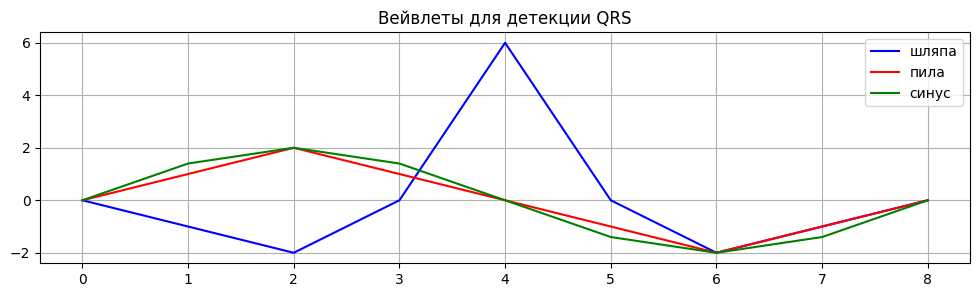

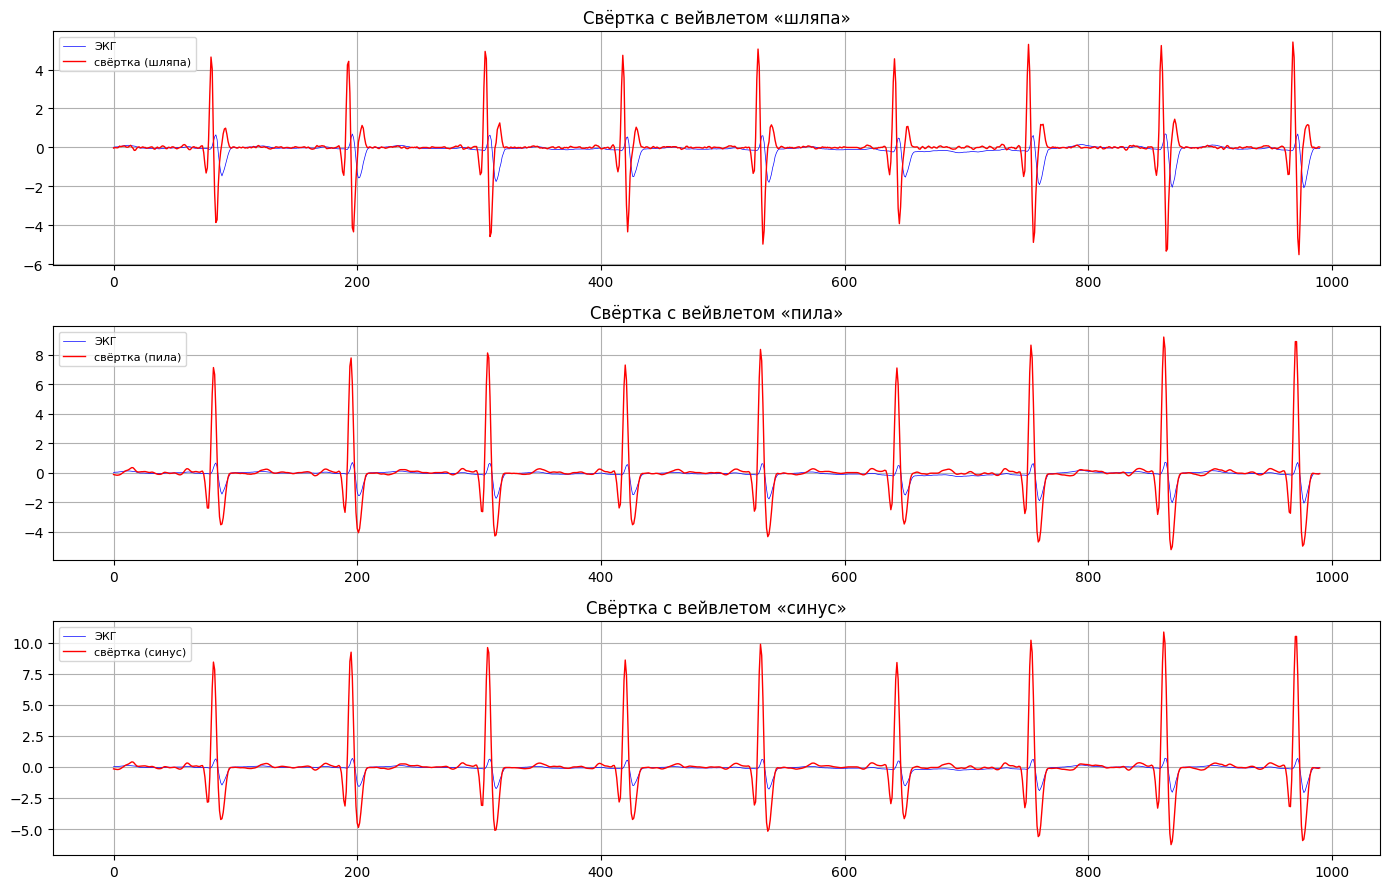

Обнаружено R-зубцов: 9
Средняя ЧСС: 108.1 уд/мин


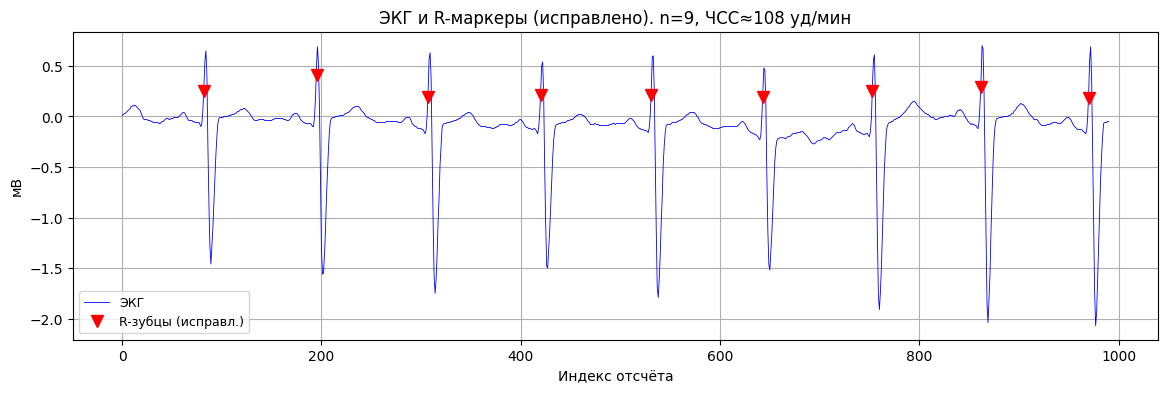

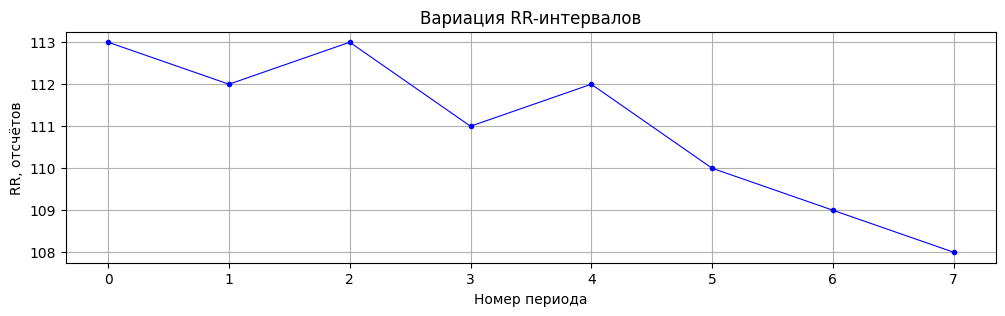

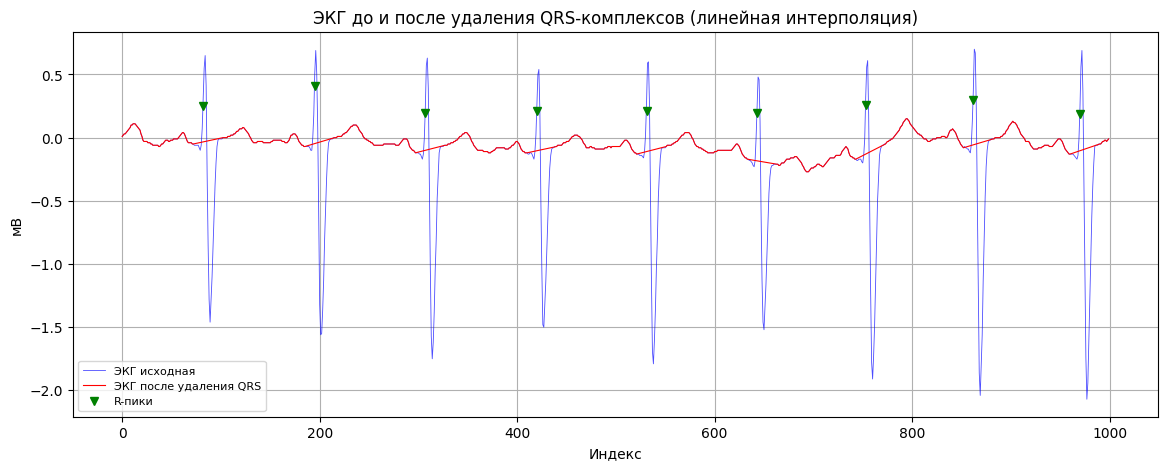

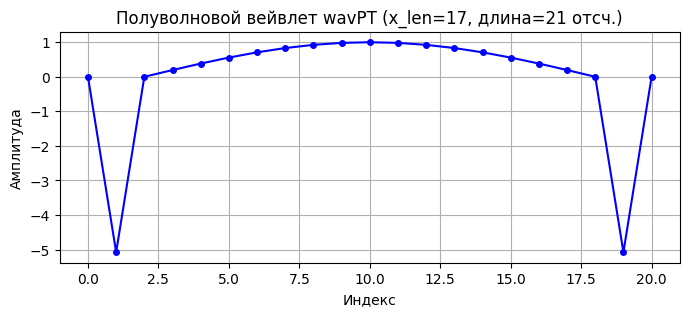

Порог wavPT: 0.2611


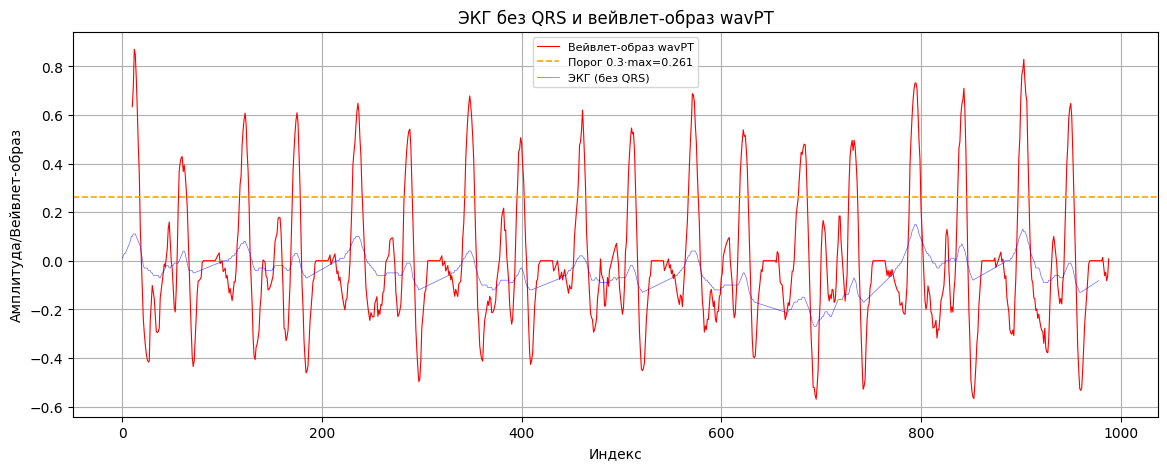

R-зубцов: 9,  P-зубцов: 9,  T-зубцов: 8
Доля P: 100.0%,  Доля T: 88.9%


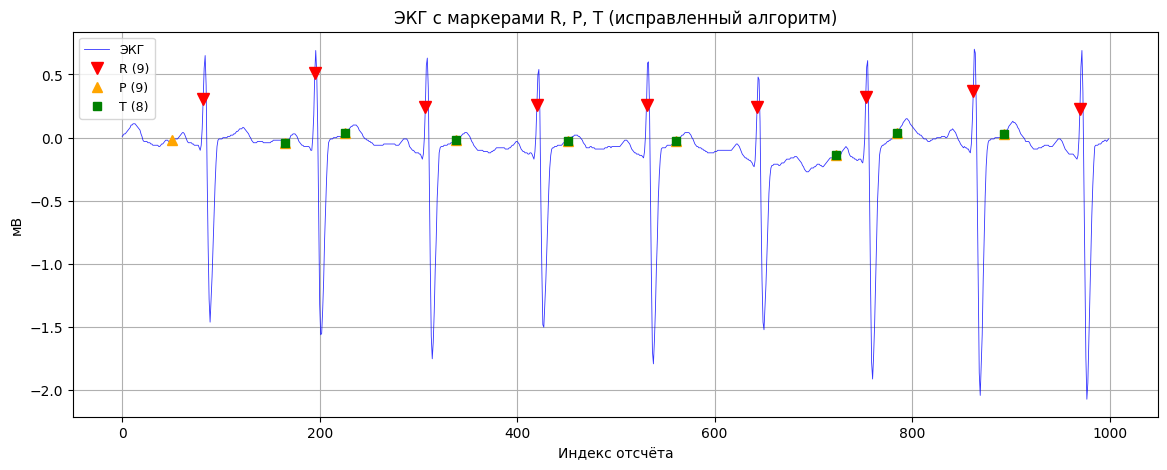

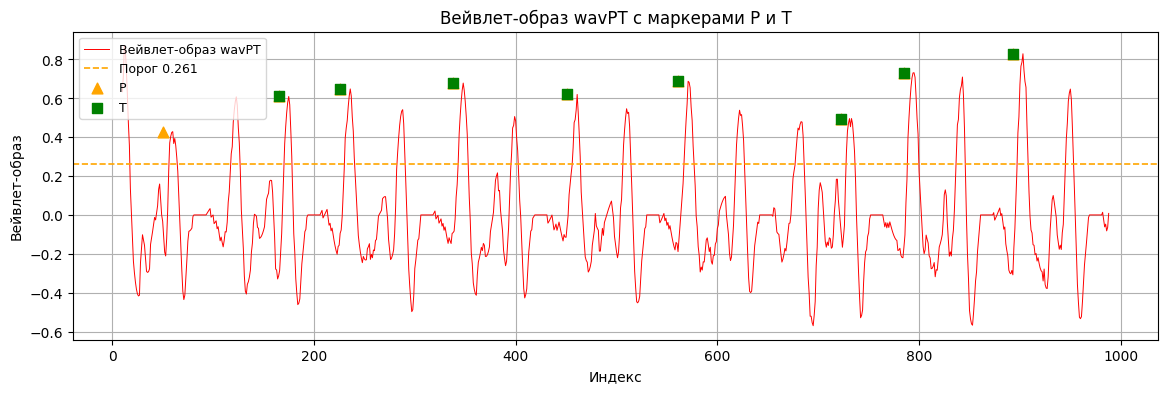

In [ ]:
import numpy as np

def read_edf_channel(fid, channel=0):
    """
    Читает один канал из EDF/EDF+ файла РОХМИНЭ.

    Параметры:
        fid     : str — путь к EDF-файлу
        channel : int — индекс канала (0-based, 0=V2-Ref, 1=V5-Ref, 2=avF-Ref)

    Возвращает:
        data_s  : list[float] — сигнал в мВ
        fs      : float — частота дискретизации, Гц
        meta    : dict — метаданные (patientID, startdate, starttime, labels, ...)
    """
    with open(fid, 'rb') as f:
        # ── Общий заголовок (256 байт) ──────────────────────────────────────
        vers      = f.read(8).decode('utf-8').strip()
        patientID = f.read(80).decode('utf-8').strip()
        recordID  = f.read(80).decode('utf-8').strip()
        startdate = f.read(8).decode('utf-8').strip()
        starttime = f.read(8).decode('utf-8').strip()
        numBytes  = int(f.read(8).decode('utf-8').strip())
        reserved  = f.read(44).decode('utf-8').strip()
        numRec    = int(f.read(8).decode('utf-8').strip())
        duration  = float(f.read(8).decode('utf-8').strip())
        ns        = int(f.read(4).decode('utf-8').strip())

        # ── Сигнальный заголовок (256 × ns байт) ────────────────────────────
        label      = [f.read(16).decode('utf-8').strip() for _ in range(ns)]
        transducer = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        units      = [f.read(8).decode('utf-8').strip()  for _ in range(ns)]
        physMin    = [float(f.read(8)) for _ in range(ns)]
        physMax    = [float(f.read(8)) for _ in range(ns)]
        digMin     = [float(f.read(8)) for _ in range(ns)]
        digMax     = [float(f.read(8)) for _ in range(ns)]
        prefilter  = [f.read(80).decode('utf-8').strip() for _ in range(ns)]
        samples    = [int(f.read(8))   for _ in range(ns)]
        reserv_ns  = [f.read(32).decode('utf-8').strip() for _ in range(ns)]

        # ── Масштабный коэффициент и смещение нуля ──────────────────────────
        scalefac = [(physMax[i]-physMin[i])/(digMax[i]-digMin[i])
                    if digMax[i] != digMin[i] else 1.0 for i in range(ns)]
        dc       = [physMax[i] - scalefac[i]*digMax[i] for i in range(ns)]

        fs = samples[channel] / duration   # Гц

        # ── Чтение данных: цикл по записям ─────────────────
        # для каждой из numRec записей читаем samples[ch] отсчётов канала
        data_s = []
        for rec in range(numRec):
            # Пропускаем данные каналов до нужного
            for ch_idx in range(ns):
                n = samples[ch_idx]
                raw_bytes = f.read(n * 2)
                if ch_idx == channel:
                    for i in range(n):
                        val = int.from_bytes(raw_bytes[i*2:(i+1)*2],
                                             byteorder='little', signed=True)
                        data_s.append(val * scalefac[channel] + dc[channel])

    meta = {'vers':vers,'patientID':patientID,'recordID':recordID,
            'startdate':startdate,'starttime':starttime,'numBytes':numBytes,
            'numRec':numRec,'duration':duration,'ns':ns,'labels':label,
            'units':units,'samples':samples,'fs':fs}
    return data_s, fs, meta

# ── Чтение файла ────────────────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# fid = list(uploaded.keys())[0]

fid = 'gusa.edf'
data_s, fs, meta = read_edf_channel(fid, channel=0)
print(f"Файл:       {fid}")
print(f"Пациент:    {meta['patientID']}")
print(f"Дата/Время: {meta['startdate']} {meta['starttime']}")
print(f"Каналы:     {meta['labels']}")
print(f"fs:         {fs} Гц")
print(f"Длина:      {len(data_s)} отсч. = {len(data_s)/fs/60:.1f} мин")
print(f"Диапазон:   {min(data_s):.3f} .. {max(data_s):.3f} {meta['units'][0]}")


# ─────────────────────────────────────────────────────────────────────────────
# ИДЕНТИФИКАЦИЯ R-ЗУБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

# Диапазон для анализа (в отсчётах)
range_beg = 0
range_end = min(1000, len(data_s))

# ── Вейвлеты ────────────────────────────────────────────────────────────────
wav1 = (0, -1, -2, 0, 6, 0, -2, -1, 0)   # «мексиканская шляпа»
wav2 = (0,  1,  2, 1, 0, -1, -2, -1, 0)  # «пила»
wav3 = (0, 1.4, 2, 1.4, 0, -1.4, -2, -1.4, 0)  # «синус»

x_wav = list(range(9))
plt.figure(figsize=(12, 3))
for wav, name, col in [(wav1,'шляпа','b'),(wav2,'пила','r'),(wav3,'синус','g')]:
    plt.plot(x_wav, wav, f'{col}-', lw=1.5, label=name)
plt.title('Вейвлеты для детекции QRS'); plt.legend(); plt.grid(True); plt.show()

# ── Свёртки ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, wav, name in zip(axes, [wav1, wav2, wav3], ['шляпа', 'пила', 'синус']):
    xs = list(range(range_beg, range_end - len(wav)))
    ws = []
    for kk in range(range_beg, range_end - len(wav)):
        integr = 0
        for ii in range(len(wav)):
            integr += data_s[kk + ii] * wav[ii]
        ws.append(integr)
    ax.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.5, label='ЭКГ')
    ax.plot(xs, ws, 'r-', lw=1.0, label=f'свёртка ({name})')
    ax.set_title(f'Свёртка с вейвлетом «{name}»'); ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

# ── Детекция R: синус-вейвлет + порог ────────────────────────────────────────
wav = wav3   # выбран синус как лучший для QRS
xs  = list(range(range_beg, range_end - len(wav)))
ws  = []
for kk in range(range_beg, range_end - len(wav)):
    integr = sum(data_s[kk + ii] * wav[ii] for ii in range(len(wav)))
    ws.append(integr)

# Порог: фиксированное значение (как в оригинале) или адаптивный mean+2σ
porog = 6   # фиксированный порог (оригинал)
# Адаптивный вариант (рекомендуется):
# import numpy as np; porog = np.mean(ws) + 2*np.std(ws)

ws_corr = [max(0, w - porog) for w in ws]


indR = []
yR   = []
ii = 1; tmp_max = 0; flag = False
while ii <= len(ws_corr) - 1:
    if ws_corr[ii] > tmp_max:
        tmp_max = ws_corr[ii]; flag = True
    else:
        if flag:
            indR.append(range_beg + ii - 1)
            yR.append(data_s[range_beg + ii - 1] * 0.8)
            tmp_max = ws_corr[ii]; flag = False
        else:
            tmp_max = ws_corr[ii]
    ii += 1

print(f"Обнаружено R-зубцов: {len(indR)}")
if len(indR) > 1:
    deltaR = [indR[i+1] - indR[i] for i in range(len(indR)-1)]
    bpm = 60 * fs / (sum(deltaR) / len(deltaR))
    print(f"Средняя ЧСС: {bpm:.1f} уд/мин")

# График: ЭКГ с R-маркерами
plt.figure(figsize=(14, 4))
plt.plot(xs, data_s[range_beg:range_end - len(wav)], 'b-', lw=0.6, label='ЭКГ')
plt.plot(indR, yR, 'rv', ms=8, zorder=5, label='R-зубцы (исправл.)')
plt.xlabel('Индекс отсчёта'); plt.ylabel('мВ')
plt.title(f'ЭКГ и R-маркеры (исправлено). n={len(indR)}, ЧСС≈{bpm:.0f} уд/мин')
plt.legend(fontsize=9); plt.grid(True); plt.show()

# График RR-интервалов
if len(indR) > 1:
    plt.figure(figsize=(12, 3))
    plt.plot(deltaR, 'b-o', ms=3, lw=0.8)
    plt.xlabel('Номер периода'); plt.ylabel('RR, отсчётов')
    plt.title('Вариация RR-интервалов'); plt.grid(True); plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# ФИЛЬТРАЦИЯ QRS И ДЕТЕКЦИЯ P/T-ЗУБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

data_f = data_s.copy()

# ── Детекция R (используются indR из предыдущей ячейки) ──────────────────────
# Если indR не определён — запускается сначала ячейку детекции R

# ── Процедура фильтрации QRS: замена интерполяцией ────────────────────────────
# Расширено окно вырезания QRS
#   ±50 мс слева, +100 мс справа (охватывает QRS 80–120 мс)
jleft_ms  = 50   # мс до R
jrigth_ms = 100  # мс после R
jleft_n   = int(jleft_ms  / 1000 * fs)   # отсчётов
jrigth_n  = int(jrigth_ms / 1000 * fs)   # отсчётов

for ii in range(len(indR)):
    jleft  = max(0, indR[ii] - jleft_n)
    jrigth = min(len(data_f) - 1, indR[ii] + jrigth_n)
    if jrigth - jleft < 2:
        continue
    # Линейная интерполяция между data_f[jleft] и data_f[jrigth]
    k_a = (data_f[jrigth] - data_f[jleft]) / (jrigth - jleft)
    for jj in range(jleft, jrigth):
        data_f[jj] = data_f[jleft] + (jj - jleft) * k_a
        # Здесь data_f изменяется, data_s — НЕТ (благодаря .copy())

# Контроль фильтрации
xs_plot = list(range(range_beg, range_end))
plt.figure(figsize=(14, 5))
plt.plot(xs_plot, data_s[range_beg:range_end], 'b-', lw=0.6, alpha=0.7, label='ЭКГ исходная')
plt.plot(xs_plot, data_f[range_beg:range_end], 'r-', lw=0.8, label='ЭКГ после удаления QRS')
plt.plot(indR, [data_s[r]*0.8 for r in indR if range_beg<=r<range_end],
         'gv', ms=6, zorder=5, label='R-пики')
plt.xlabel('Индекс'); plt.ylabel('мВ')
plt.title('ЭКГ до и после удаления QRS-комплексов (линейная интерполяция)')
plt.legend(fontsize=8); plt.grid(True); plt.show()

# ── Вейвлет PT ────────────────────────────────────────────────────────────────
x_len = 17   # точек положительного полупериода ≈ 85 мс при fs=200 Гц

y_sin = [math.sin(math.pi * ii / (x_len - 1)) for ii in range(x_len)]
sq_w  = sum((y_sin[ii] + y_sin[ii+1]) / 2 for ii in range(len(y_sin) - 1))
a_neg = sq_w / 2   # амплитуда отрицательных крыльев

wavPT = [0, -a_neg] + y_sin + [-a_neg, 0]
x_PT  = list(range(len(wavPT)))

plt.figure(figsize=(8, 3))
plt.plot(x_PT, wavPT, 'b-o', ms=4, lw=1.5)
plt.title(f'Полуволновой вейвлет wavPT (x_len={x_len}, длина={len(wavPT)} отсч.)')
plt.xlabel('Индекс'); plt.ylabel('Амплитуда'); plt.grid(True); plt.show()

# ── Вейвлет-образ для PT ──────────────────────────────────────────────────────
xs  = []
xsc = []
for ii in range(range_beg, range_end - len(wavPT)):
    xs.append(ii)
    xsc.append(ii + math.floor(len(wavPT) / 2))  # центровка: half = L//2

ws_pt = []
for kk in range(range_beg, range_end - len(wavPT)):
    integr = sum(data_f[kk + ii] * wavPT[ii] for ii in range(len(wavPT)))
    ws_pt.append(integr)

# Порог: 30% от максимума вейвлет-образа
if ws_pt:
    thr_pt = 0.3 * max(ws_pt)
    print(f"Порог wavPT: {thr_pt:.4f}")
else:
    thr_pt = 0

plt.figure(figsize=(14, 5))
plt.plot(xsc, ws_pt, 'r-', lw=0.8, label='Вейвлет-образ wavPT')
plt.axhline(thr_pt, color='orange', ls='--', lw=1.2, label=f'Порог 0.3·max={thr_pt:.3f}')
plt.plot(xs,  data_f[range_beg:range_end - len(wavPT)], 'b-', lw=0.5, alpha=0.6, label='ЭКГ (без QRS)')
plt.xlabel('Индекс'); plt.ylabel('Амплитуда/Вейвлет-образ')
plt.title('ЭКГ без QRS и вейвлет-образ wavPT')
plt.legend(fontsize=8); plt.grid(True); plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# ИДЕНТИФИКАЦИЯ P- И T-ЗУБЦОВ (исправленная версия Cell 6)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import math

# ВНИМАНИЕ: эта ячейка требует предварительного выполнения:
#   1. Ячейки чтения EDF (data_s, fs, meta)
#   2. Ячейки детекции R (indR, range_beg, range_end, wav)
#   3. Ячейки фильтрации QRS (data_f, wavPT, thr_pt, xsc, ws_pt)

# ── Детекция P-зубцов в каждом RR-интервале ──────────────────────────────────
# P ищется в первых 5/6 интервала ПЕРЕД R-зубцом
indP = []
yP   = []
for k in range(len(indR)):
    r_curr = indR[k]
    r_prev = indR[k-1] if k > 0 else max(0, r_curr - int(fs))
    rr = r_curr - r_prev

    p_start = r_prev + max(1, rr // 6)
    p_end   = r_curr - max(1, rr // 6)
    if p_start >= p_end or p_end > len(ws_pt): continue

    # Ищем максимум вейвлет-образа в зоне P, превышающий порог
    # Переводим индексы data_f в индексы ws_pt (ws_pt начинается с range_beg)
    ws_p_zone = ws_pt[max(0, p_start-range_beg): max(0, p_end-range_beg)]
    if not ws_p_zone or max(ws_p_zone) <= thr_pt: continue

    local_max = ws_p_zone.index(max(ws_p_zone))
    p_idx = p_start + local_max
    indP.append(p_idx)
    yP.append(data_f[p_idx] if p_idx < len(data_f) else 0)

# ── Детекция T-зубцов в каждом RR-интервале ──────────────────────────────────
# T ищется от 1/5 до 3/4 интервала ПОСЛЕ R-зубца
indT = []
yT   = []
for k in range(len(indR)):
    r_curr = indR[k]
    r_next = indR[k+1] if k < len(indR)-1 else min(len(data_f)-1, r_curr + int(fs))
    rnn = r_next - r_curr

    t_start = r_curr + max(1, rnn // 5)
    t_end   = r_curr + min(rnn - 1, int(0.75 * rnn))
    if t_start >= t_end or t_end > len(ws_pt): continue

    ws_t_zone = ws_pt[max(0, t_start-range_beg): max(0, t_end-range_beg)]
    if not ws_t_zone or max(ws_t_zone) <= thr_pt: continue

    local_max = ws_t_zone.index(max(ws_t_zone))
    t_idx = t_start + local_max
    indT.append(t_idx)
    yT.append(data_f[t_idx] if t_idx < len(data_f) else 0)

print(f"R-зубцов: {len(indR)},  P-зубцов: {len(indP)},  T-зубцов: {len(indT)}")
print(f"Доля P: {100*len(indP)/max(len(indR),1):.1f}%,  Доля T: {100*len(indT)/max(len(indR),1):.1f}%")

# ── График: ЭКГ с маркерами R, P, T ─────────────────────────────────────────
xs_ecg = list(range(range_beg, range_end))
plt.figure(figsize=(14, 5))
plt.plot(xs_ecg, data_s[range_beg:range_end], 'b-', lw=0.6, alpha=0.8, label='ЭКГ')

r_in_range = [r for r in indR  if range_beg <= r < range_end]
p_in_range = [p for p in indP  if range_beg <= p < range_end]
t_in_range = [t for t in indT  if range_beg <= t < range_end]

if r_in_range: plt.plot(r_in_range, [data_s[r] for r in r_in_range],
                        'rv', ms=8, zorder=5, label=f'R ({len(r_in_range)})')
if p_in_range: plt.plot(p_in_range, [data_f[p] for p in p_in_range],
                        '^', color='orange', ms=7, zorder=5, label=f'P ({len(p_in_range)})')
if t_in_range: plt.plot(t_in_range, [data_f[t] for t in t_in_range],
                        's', color='green',  ms=6, zorder=5, label=f'T ({len(t_in_range)})')

plt.xlabel('Индекс отсчёта'); plt.ylabel('мВ')
plt.title('ЭКГ с маркерами R, P, T (исправленный алгоритм)')
plt.legend(fontsize=9); plt.grid(True); plt.show()

# ── Вейвлет-образ и маркеры ──────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(xsc, ws_pt, 'r-', lw=0.7, label='Вейвлет-образ wavPT')
plt.axhline(thr_pt, color='orange', ls='--', lw=1.2, label=f'Порог {thr_pt:.3f}')
if p_in_range:
    p_ws = [ws_pt[p - range_beg] if 0 <= p-range_beg < len(ws_pt) else 0 for p in p_in_range]
    plt.scatter(p_in_range, p_ws, marker='^', color='orange', s=60, zorder=5, label='P')
if t_in_range:
    t_ws = [ws_pt[t - range_beg] if 0 <= t-range_beg < len(ws_pt) else 0 for t in t_in_range]
    plt.scatter(t_in_range, t_ws, marker='s', color='green',  s=50, zorder=5, label='T')
plt.xlabel('Индекс'); plt.ylabel('Вейвлет-образ')
plt.title('Вейвлет-образ wavPT с маркерами P и T')
plt.legend(fontsize=9); plt.grid(True); plt.show()

Найдено R-пиков на фрагменте: 8
Времена R-пиков: [301.185 301.72  302.24  302.77  303.305 303.83  304.355 304.895]


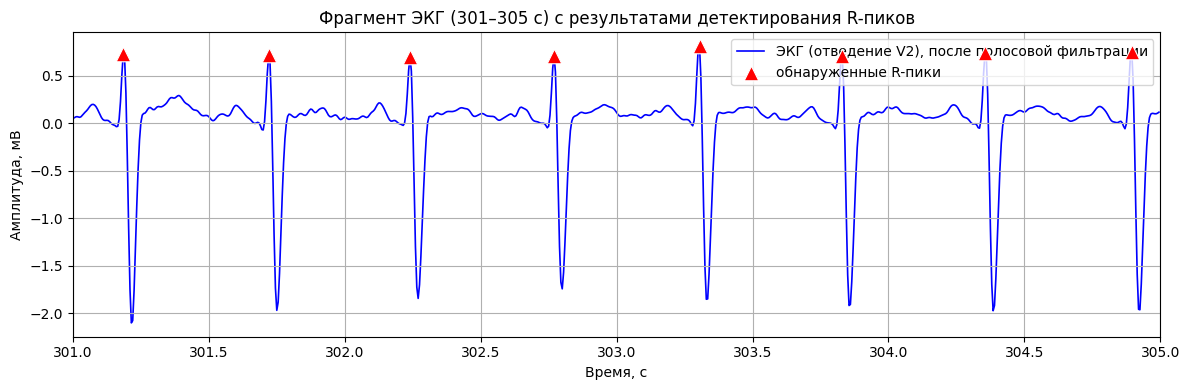

Количество всех пиков: 6625
Пики в диапазоне 301–305 с: 8
Времена пиков: [301.185 301.72  302.24  302.77  303.305 303.83  304.355 304.895]
Минимальный/максимальный индекс: 196 665925
Длина сигнала: 666000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- загрузка ранее рассчитанных результатов (не пересчитываем заново) ---
results = np.load('results_final.npy', allow_pickle=True).item()
fs = 200.0
lab = 'ECG V2-Ref'
r = results[lab]

sig_f = r['sig_f']   # отфильтрованный сигнал ЭКГ (0.5-40 Гц)
peaks = r['peaks']   # индексы найденных R-пиков (в отсчётах)

# диапазон построения
t0, t1 = 301, 305
i0, i1 = int(t0 * fs), int(t1 * fs)

t = np.arange(i0, i1) / fs
y = sig_f[i0:i1]

# R-пики внутри диапазона и внутри длины сигнала
pk_in = peaks[
    (peaks >= i0) &
    (peaks < i1) &
    (peaks >= 0) &
    (peaks < len(sig_f))
]

print("Найдено R-пиков на фрагменте:", len(pk_in))
print("Времена R-пиков:", pk_in / fs)

plt.figure(figsize=(12, 4))

plt.plot(
    t, y,
    color='blue',
    lw=1.2,
    label='ЭКГ (отведение V2), после полосовой фильтрации',
    zorder=1
)

plt.scatter(
    pk_in / fs,
    sig_f[pk_in],
    marker='^',
    s=110,
    color='red',
    edgecolors='white',
    linewidths=0.8,
    label='обнаруженные R-пики',
    zorder=10
)
plt.grid(True)
plt.xlim(t0, t1)
plt.xlabel('Время, с')
plt.ylabel('Амплитуда, мВ')
plt.title('Фрагмент ЭКГ (301–305 с) с результатами детектирования R-пиков')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figure1_301_305s.png', dpi=150)
plt.show()
print("Количество всех пиков:", len(peaks))
print("Пики в диапазоне 301–305 с:", len(pk_in))
print("Времена пиков:", pk_in / fs)
print("Минимальный/максимальный индекс:", peaks.min(), peaks.max())
print("Длина сигнала:", len(sig_f))